In [1]:
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [2]:
DATA_DIR = '/home/HDD6TB/datasets/emotions/ABAW/ABAW_10/ABAW_Annotations'

In [3]:
import os
from PIL import Image
import cv2
import pathlib

from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn import svm,metrics,preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score,roc_auc_score,average_precision_score

from collections import defaultdict
import os
import glob
import gc
import random
import numpy as np
from tqdm import tqdm
import time
import pickle
import pandas as pd
import random
import csv  
import matplotlib.pyplot as plt

In [4]:
def get_names(id):
    name = ""
    if id>=0 and id<10:
        name = "0000" + str(id)
    elif id>=10 and id<100:
        name = "000" + str(id)
    elif id>=100 and id<1000:
        name = "00" + str(id)
    elif id>=1000 and id<10000:
        name = "0" + str(id)
    else:
        name = str(id)
    return name

In [5]:
compare_filenames=lambda x: int(os.path.splitext(x)[0])

# Extract Features

## LibreFace

In [6]:
import sys
sys.path.append('/home/avsavchenko/src/distr/LibreFace')
import libreface

2026-03-09 18:58:46.164333: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-09 18:58:46.235883: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-09 18:58:46.235915: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-09 18:58:46.236065: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-09 18:58:46.246242: I tensorflow/core/platform/cpu_feature_g

In [7]:
def get_aligned_facial_attributes_image(aligned_image_path:str, 
                                model_choice:str="joint_au_detection_intensity_estimator", 
                                temp_dir:str="./tmp", 
                                device:str="cpu",
                                weights_download_dir:str = "./weights_libreface")->dict:
    """Get facial attributes for an image. This function reads an image and returns a dictionary containing
    some detected facial action units and expressions.

    Args:
        aligned_image_path (str): Input image path.
        model_choice (str, optional): Model to use when doing predictions. Defaults to "joint_au_detection_intensity_estimator".
        temp_dir (str, optional): Path where the temporary aligned image, facial landmarks 
        and landmark annotated image will be stored. Defaults to "./tmp".
        device (str, optional): device to be used for inference. Can be "cpu" or "cuda". Defaults to "cpu".
        weights_download_dir(str, optional): directory where you want to download and save the model weights.

    Returns:
        dict: dictionary containing the following keys
            input_image_path - copied from the image_path
            aligned_image_path - path to the aligned image, i.e. image with the only the face of the person cropped from original image
            detected_action_units - dictionary of detected action units. Units which are detected have value of 1, else 0.
            au_intensities - dictionary of action unit intensities, with each intensity in the range (0, 5)
            facial_expression - detected facial expression. Can be one from ["Neutral", "Happiness", "Sadness", "Surprise", "Fear", "Disgust", "Anger", "Contempt"]
    """
    
    #print(f"Using device: {device} for inference...")
    #aligned_image_path, headpose, landmarks_2d = get_aligned_image(image_path, temp_dir=temp_dir, verbose=True)
    if model_choice == "joint_au_detection_intensity_estimator":
        detected_aus, au_intensities = libreface.get_au_intensities_and_detect_aus(aligned_image_path, device=device, weights_download_dir=weights_download_dir)
    elif model_choice == "separate_prediction_heads":
        detected_aus = libreface.detect_action_units(aligned_image_path, device = device, weights_download_dir=weights_download_dir)
        au_intensities = libreface.get_au_intensities(aligned_image_path, device = device, weights_download_dir=weights_download_dir)
    else:
        print(f"Undefined model_choice = {model_choice} for get_facial_attributes_image()")
        raise NotImplementedError
    facial_expression,expr_logits = libreface.get_facial_expression(aligned_image_path, device = device, weights_download_dir=weights_download_dir,final_expr=False)
    return_dict =  {
            "detected_aus": detected_aus,
            "au_intensities": au_intensities,
            "facial_expression_logits": expr_logits,
            "facial_expression": facial_expression}
    
    #return_dict = {**return_dict, **headpose, **landmarks_2d}

    return return_dict


import pandas as pd
def get_facial_attributes_aligned_photos_list(aligned_frames_path_list, 
                                model_choice:str="joint_au_detection_intensity_estimator", 
                                temp_dir="./tmp", 
                                device="cpu",
                                batch_size = 128,
                                num_workers = 2,
                                weights_download_dir:str = "./weights_libreface"):
    detected_aus, au_intensities, facial_expression, expr_logits = [], [], [], []
    
    if model_choice == "joint_au_detection_intensity_estimator":
        detected_aus, au_intensities = libreface.get_au_intensities_and_detect_aus_video(aligned_frames_path_list, 
                                                                           device = device, 
                                                                           batch_size=batch_size,
                                                                           num_workers=num_workers,
                                                                           weights_download_dir=weights_download_dir)
    elif model_choice == "separate_prediction_heads":
        detected_aus = libreface.detect_action_units_video(aligned_frames_path_list, 
                                                device=device,
                                                batch_size=batch_size,
                                                num_workers=num_workers,
                                                weights_download_dir=weights_download_dir)
        au_intensities = libreface.get_au_intensities_video(aligned_frames_path_list, 
                                                device=device,
                                                batch_size=batch_size,
                                                num_workers=num_workers,
                                                weights_download_dir=weights_download_dir)
    else:
        print(f"Undefined model_choice = {model_choice} for get_facial_attributes_video()")
        raise NotImplementedError
    
    facial_expression,expr_logits = libreface.get_facial_expression_video(aligned_frames_path_list, 
                                                    device = device, 
                                                    batch_size=batch_size,
                                                    weights_download_dir=weights_download_dir,final_expr=False)
    

    return detected_aus, au_intensities, facial_expression, expr_logits

In [8]:
detected_attributes = get_aligned_facial_attributes_image(os.path.join(DATA_DIR,'cropped','403/00222.jpg'),device='cuda')
print(detected_attributes)

{'detected_aus': {'au_1': 0, 'au_2': 0, 'au_4': 0, 'au_6': 0, 'au_7': 1, 'au_10': 0, 'au_12': 0, 'au_14': 1, 'au_15': 1, 'au_17': 1, 'au_23': 1, 'au_24': 1}, 'au_intensities': {'au_1_intensity': 0.016, 'au_2_intensity': 0.023, 'au_4_intensity': 0.084, 'au_5_intensity': 0.019, 'au_6_intensity': 0.079, 'au_9_intensity': 0.022, 'au_12_intensity': 0.011, 'au_15_intensity': 0.117, 'au_17_intensity': 0.393, 'au_20_intensity': 0.321, 'au_25_intensity': 0.001, 'au_26_intensity': 0.02}, 'facial_expression_logits': array([2.2432800e-01, 9.9999988e-01, 2.9389719e-03, 1.0029494e-03,
       5.2057108e-04, 3.2558790e-04, 1.8824490e-04, 1.4858069e-04],
      dtype=float32), 'facial_expression': 'Happiness'}


In [9]:
#aligned_frames_path_list=[os.path.join(DATA_DIR,'cropped','403/00222.jpg'),os.path.join(DATA_DIR,'cropped','403/00223.jpg')]
aligned_frames_path_list=[os.path.join(DATA_DIR,'cropped','403',fn) for fn in os.listdir(os.path.join(DATA_DIR,'cropped','403'))]
detected_aus, au_intensities, facial_expression, expr_logits=get_facial_attributes_aligned_photos_list(aligned_frames_path_list,device='cuda')
print(detected_aus, au_intensities, facial_expression, expr_logits)

      au_1  au_2  au_4  au_6  au_7  au_10  au_12  au_14  au_15  au_17  au_23  \
0        0     0     0     0     1      0      0      1      1      1      1   
1        0     0     0     0     1      0      0      1      1      1      1   
2        0     0     0     1     1      1      1      1      0      1      1   
3        0     0     0     0     0      0      0      1      0      1      0   
4        0     0     0     0     0      0      0      1      1      1      1   
...    ...   ...   ...   ...   ...    ...    ...    ...    ...    ...    ...   
2160     0     0     0     0     1      0      0      1      1      1      1   
2161     0     0     0     0     0      0      0      1      0      1      0   
2162     0     0     0     0     0      0      0      1      1      1      1   
2163     0     0     0     0     0      0      0      1      1      1      1   
2164     0     0     0     0     0      0      0      1      0      1      1   

      au_24  
0         1  
1         1

In [11]:
data_dir=os.path.join(DATA_DIR,'cropped')
print(data_dir)
video2libreface_features={}
for filename in tqdm(os.listdir(data_dir)):
    frames_dir=os.path.join(data_dir,filename)   
    if not os.path.isdir(frames_dir):
        continue

    aligned_frames_path_list=[os.path.join(frames_dir,img_name) for img_name in sorted(os.listdir(frames_dir)) if img_name.lower().endswith('.jpg')]
    video2libreface_features[filename]=get_facial_attributes_aligned_photos_list(aligned_frames_path_list,device='cuda')
    #detected_aus, au_intensities, facial_expression, expr_logits
    #print(detected_aus, au_intensities, facial_expression, expr_logits)

/home/HDD6TB/datasets/emotions/ABAW/ABAW_10/ABAW_Annotations/cropped


100%|█████████████████████████████████████████████████████████████| 594/594 [5:30:12<00:00, 33.35s/it]


In [12]:
import pickle
model_name='libfreface'
#MODEL2FEATURES=model_name+'_aligned_112.pickle'
MODEL2FEATURES=model_name+'_cropped.pickle' 

print(MODEL2FEATURES)
if True:
    with open(MODEL2FEATURES, 'wb') as handle:
        pickle.dump(video2libreface_features, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    filename=MODEL2FEATURES
    with open(filename, 'rb') as handle:
        video2libreface_features=pickle.load(handle)
    print(filename,len(video2libreface_features))


libfreface_cropped.pickle


In [24]:
len(video2libreface_features),filename,len(os.listdir(data_dir)),video2libreface_features[filename]

(594,
 '172',
 594,
 (       au_1  au_2  au_4  au_6  au_7  au_10  au_12  au_14  au_15  au_17  au_23  \
  0         0     0     1     0     0      0      0      0      0      1      0   
  1         0     0     1     0     0      0      0      0      0      1      0   
  2         0     0     0     0     0      0      0      1      0      0      0   
  3         0     0     1     0     0      0      0      0      0      1      0   
  4         0     0     1     0     0      0      0      0      0      1      0   
  ...     ...   ...   ...   ...   ...    ...    ...    ...    ...    ...    ...   
  11328     0     1     1     0     0      0      0      0      0      1      0   
  11329     0     0     1     0     0      0      0      0      0      1      0   
  11330     0     0     1     0     0      0      0      0      0      1      0   
  11331     0     0     0     0     0      0      0      1      0      1      0   
  11332     0     0     0     0     0      0      0      1      0  

## Our models

In [6]:
import glob
from itertools import chain
import os
import random
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm.notebook import tqdm

print(f"Torch: {torch.__version__}")
device = 'cuda'
use_cuda = torch.cuda.is_available()
print(use_cuda)

Torch: 2.7.1+cu118
True


In [7]:
#num_classes=7
if False:
    #PATH='affectnet_vggface2_enet2_gmp_smooth.pt'
    PATH='enet_b2_8_best.pt'
    #PATH='enet_b2_7.pt'
    IMG_SIZE=260 #224 #
else:
    #PATH='affectnet_vggface2_enet0.pt'
    #PATH='affectnet_vggface2_enet0_new.pt'
    #PATH='enet_b0_7.pt'
    #PATH='enet_b0_8_best_afew.pt'
    PATH='enet_b0_8_best_vgaf.pt'
    #PATH='mobilevit_mtl_new.pt'
    
    #PATH='enet_b0_8_va_mtl.pt'
    IMG_SIZE=224
    
#IMG_SIZE=112

test_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        #transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    ]
)
np_transforms = transforms.Compose(
    [
        transforms.ToPILImage(None),
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        #transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    ]
)


In [6]:
print(PATH)
feature_extractor_model = torch.load('/home/avsavchenko/src/face-emotion-recognition/models/affectnet_emotions/'+PATH)

enet_b0_8_best_vgaf.pt


In [8]:
PATH='/home/avsavchenko/src/emotions-multimodal/faces/torch_models/enet_b0_va.pt'
feature_extractor_model = torch.load(PATH,weights_only=False)

In [10]:
if False:
    classifier_weights=feature_extractor_model.classifier[0].weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.classifier[0].bias.cpu().data.numpy()
elif True:
    classifier_weights=feature_extractor_model.classifier.weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.classifier.bias.cpu().data.numpy()
elif False:
    classifier_weights=feature_extractor_model.head.fc.weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.head.fc.bias.cpu().data.numpy()
else:
    classifier_weights=feature_extractor_model.fc.weight.cpu().data.numpy()
    classifier_bias=feature_extractor_model.fc.bias.cpu().data.numpy()
print(classifier_weights.shape,classifier_weights)
print(classifier_bias.shape,classifier_bias)

(10, 1280) [[-0.02736259  0.11370759 -0.01703242 ... -0.04183695  0.02692253
   0.02082809]
 [-0.00740677 -0.28460807 -0.04788842 ...  0.00655239 -0.00819803
  -0.03571186]
 [ 0.0173537   0.13274516  0.22742319 ... -0.00110899 -0.08669303
   0.10910228]
 ...
 [ 0.0385634  -0.1280807  -0.13346949 ... -0.0663611   0.04259431
   0.12334546]
 [-0.02130484 -0.02091497  0.00577539 ...  0.00221393  0.012389
  -0.00743106]
 [-0.04188346 -0.02777942 -0.0151115  ...  0.00636553  0.02920754
  -0.04359059]]
(10,) [ 0.06728865  0.06320021 -0.0623091  -0.00546835 -0.0297699   0.00574494
 -0.08588366  0.03935008  0.09327971  0.02422165]


In [11]:
if True:
    feature_extractor_model.classifier=torch.nn.Identity()
elif False:
    feature_extractor_model.head.fc=torch.nn.Identity()
else:
    feature_extractor_model.fc=torch.nn.Identity()
feature_extractor_model=feature_extractor_model.to(device)
feature_extractor_model.eval()

EfficientNet(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=

In [12]:
def get_probab(features):
    x=np.dot(features,np.transpose(classifier_weights))+classifier_bias
    return x

In [ ]:
print(test_transforms)
img_names=[]
X_global_features=[]
imgs=[]
data_dir=os.path.join(DATA_DIR,'cropped')
print(data_dir)
for filename in tqdm(os.listdir(data_dir)):
    frames_dir=os.path.join(data_dir,filename)   
    if not os.path.isdir(frames_dir):
        continue
    for img_name in os.listdir(frames_dir):
        if img_name.lower().endswith('.jpg'):
            img = Image.open(os.path.join(frames_dir,img_name))
            img_tensor = test_transforms(img)
            if img.size:
                img_names.append(filename+'/'+img_name)
                imgs.append(img_tensor)
                if len(imgs)>=96: #96: #64: #32:        
                    features  = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
                    #features,_,_
                    features=features.data.cpu().numpy()
                    #print(features.shape)

                    if len(X_global_features)==0:
                        X_global_features=features
                    else:
                        X_global_features=np.concatenate((X_global_features,features),axis=0)
                    imgs=[]

if len(imgs)>0:        
    features  = feature_extractor_model(torch.stack(imgs, dim=0).to(device))
    #features,_,_
    features=features.data.cpu().numpy()

    if len(X_global_features)==0:
        X_global_features=features
    else:
        X_global_features=np.concatenate((X_global_features,features),axis=0)

    imgs=[]

    #X_scores=X_global_features #get_probab(X_global_features)
    #print(X_global_features.shape,X_scores.shape)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
/home/HDD6TB/datasets/emotions/ABAW/ABAW_10/ABAW_Annotations/cropped


  0%|          | 0/594 [00:00<?, ?it/s]

----------------------------------

In [ ]:
X_scores=get_probab(X_global_features)

In [ ]:
filename2featuresAll={img_name:(global_features.astype(np.float16),scores.astype(np.float16)) for img_name,global_features,scores in zip(img_names,X_global_features,X_scores)}
print(len(filename2featuresAll))
#cropped 2942996, aligned 2941546

### Save/load features 

In [8]:
import pickle
num_classes=8
model_name='enet_b0_8_best_vgaf'
#model_name='enet_b0_8_mtl_new'
#model_name='mobilevit_mtl'
#model_name='mbf_va'

#model_name='ddamfnet_8' #affectnet8_epoch4_acc0.6462
#model_name='ddamfnet_8_mtl' #affectnet8_epoch6_acc0

#model_name='enet_b0_8_va_mtl'
#MODEL2FEATURES=model_name+'_aligned_112.pickle'
MODEL2FEATURES=model_name+'_cropped.pickle' 

print(MODEL2FEATURES)

enet_b0_8_best_vgaf_cropped.pickle


In [16]:
if False:
    with open(MODEL2FEATURES, 'wb') as handle:
        pickle.dump(filename2featuresAll, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [9]:
#filename=MODEL2FEATURES
filename='../abaw5/'+MODEL2FEATURES
#filename='../abaw6/'+MODEL2FEATURES
with open(filename, 'rb') as handle:
    filename2featuresAll=pickle.load(handle)
print(filename,len(filename2featuresAll))

../abaw5/enet_b0_8_best_vgaf_cropped.pickle 2942996


In [10]:
if True:
    for filename in filename2featuresAll:
        filename2featuresAll[filename]=(filename2featuresAll[filename][0].astype(np.float16),filename2featuresAll[filename][1].astype(np.float16))

In [10]:
filename2featuresAll[filename]

(array([-0.1349,  0.0371, -0.1056, ..., -0.1842,  0.619 ,  0.1271],
       dtype=float16),
 array([-2.04 ,  3.645, -2.393, -4.902,  4.93 ,  2.621, -3.05 ,  2.633],
       dtype=float16))

In [11]:
import gc
gc.collect()

0

# Audios

In [8]:
d=os.path.join(DATA_DIR,'../../videos')
video2len={}
for filename in os.listdir(d):
    fn, ext = os.path.splitext(os.path.basename(filename))
    vid=os.path.join(d,filename)
    cap = cv2.VideoCapture(vid)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video2len[fn]=total_frames+1 #FIX ME!!! NEED TO ADD 1 to the number of frames for consistency with challeng's organizer
    print(fn,video2len[fn])

27-60-1280x720 2933
video39 10679
77-30-1280x720 5673
91-30-1920x1080 10922
360 3510
136 4488
197 1870
291 1831
16-30-1920x1080 5474
video2 2065
89-30-1080x1920 631
408 2979
110-30-270x480 9979
324 5615
14-30-1920x1080 5311
129-24-1280x720 6154
153 3678
314 2261
255 1692
284 4055
298 2837
206 4477
video84 526
387 2912
286 2678
55-25-1280x720 1506
336 4345
video52 10680
60-30-1920x1080 4565
120 3592
267 3842
121-24-1920x1080 10629
349 4055
46-30-484x360 2945
218 3850
video55 8420
368 2930
9-15-1920x1080 47435
384 3452
228 2156
video3 7802
106-30-720x1280 1405
64-24-640x360 4919
244 2322
28-30-1280x720-2 397
235 3683
video86_3 403
92-24-1920x1080 8164
376 3570
185 4053
157 2605
38-30-1920x1080 2432
video87 1823
57-25-426x240 301
4-30-1920x1080 8261
video86_2 887
video45_5 415
143 10103
114 2450
243 4121
133 461
video64 6101
125-25-1280x720 6842
video81 8434
274 3527
113 15021
video66 155
171 3977
446 2249
126-30-1080x1920 4595
168 2979
video33 7554
201 1361
video61 117
236 3674
119 4577


In [9]:
d=os.path.join(DATA_DIR,'../../new_vids')
#video2len={}
for filename in os.listdir(d):
    fn, ext = os.path.splitext(os.path.basename(filename))
    vid=os.path.join(d,filename)
    cap = cv2.VideoCapture(vid)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video2len[fn]=total_frames+1 #FIX ME!!! NEED TO ADD 1 to the number of frames for consistency with challeng's organizer
    print(fn,video2len[fn])

454 27789
471 5934
479 6080
463 22511
461 7677
453 4946
495 2907
478 10190
499 6564
459 3686
475 9559
483 14632
491 10212
489 11980
493 871
465 25064
455 779
480 4809
477 8236
497 6328
468 10229
500 3120
469 18249
474 7953
494 1700
496 7233
451 9125
458 23633
481 4701
482 6331
486 20200
498 2200
452 11545
457 14957
467 15186
464 14578
462 3758
473 10352
488 6017
476 8260
470 9102
487 11919
485 9481
456 6303
490 7312
472 9750
460 9766
466 22919
492 510
484 3596


In [6]:
import wave, struct
from fnmatch import fnmatch
video_dir=os.path.join(DATA_DIR,'../../new_vids')
audio_dir=os.path.join(DATA_DIR,'../../new_vids_audios')
for filename in os.listdir(video_dir):
    print(filename)
    video_path=os.path.join(video_dir,filename)
    fn=os.path.splitext(filename)[0]
    waveFile = os.path.join(audio_dir, fn+'.wav')
    command = "ffmpeg -i "+video_path+" -ac 1 -ar 16000 -vn "+waveFile
    #print(command)
    os.system(command=command)

454.mp4
471.avi
479.avi
463.avi
461.mp4
453.avi
495.avi
478.avi
499.avi
459.avi
475.avi
483.mp4
491.avi
489.avi
493.avi
465.avi
455.avi
480.avi
477.avi
497.mp4
468.mp4
500.avi
469.mp4
474.avi
494.mp4
496.avi
451.avi
458.avi
481.avi
482.avi
486.avi
498.avi
452.avi
457.avi
467.mp4
464.avi
462.avi
473.avi
488.avi
476.avi
470.avi
487.avi
485.avi
456.avi
490.avi
472.avi
460.mp4
466.avi
492.mp4
484.avi


---------

In [1]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model,AutoProcessor, HubertModel
import torchaudio
import torch
if False:
    processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")
    model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")
else:
    processor = AutoProcessor.from_pretrained("facebook/hubert-large-ls960-ft")
    model = HubertModel.from_pretrained("facebook/hubert-large-ls960-ft")
model.eval()

/usr/local/lib/python3.8/dist-packages/huggingface_hub/file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


HubertModel(
  (feature_extractor): HubertFeatureEncoder(
    (conv_layers): ModuleList(
      (0): HubertLayerNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (1-4): 4 x HubertLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
      (5-6): 2 x HubertLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
        (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): HubertFeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=1024, bias=True)
    (dropout): Dropout(p=

In [7]:
AUDIO_DIR=DATA_DIR+'/../../audios'
videoname2audiofeatures={}
for filename in sorted(os.listdir(AUDIO_DIR)):
    videoname,_=os.path.splitext(filename)
    array, fs = torchaudio.load(os.path.join(AUDIO_DIR,filename))
    inp = processor(array.squeeze(), sampling_rate=fs, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inp)
    videoname2audiofeatures[videoname]=outputs.last_hidden_state.numpy()[0]
    print(videoname,fs,videoname2audiofeatures[videoname].shape,inp['input_values'].shape[1]/len(videoname2audiofeatures[videoname]))
    break

1-30-1280x720 16000 (17259, 768) 320.0136160843618


In [ ]:
import librosa

AUDIO_DIR=DATA_DIR+'/../../audios'
videoname2audiofeatures={}
for filename in tqdm(sorted(os.listdir(AUDIO_DIR))):
    videoname,_=os.path.splitext(filename)
    filepath=os.path.join(AUDIO_DIR,filename)
    fs=librosa.get_samplerate(filepath)
    stream = librosa.stream(
        filepath,
        block_length=360,
        frame_length=16000,
        hop_length=16000
    )
    total_outputs=None
    for speech in stream:
        if len(speech.shape) > 1:
            speech = speech[:, 0] + speech[:, 1]

        inp = processor(speech, sampling_rate=16000, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inp)
        outputs=outputs.last_hidden_state.numpy()[0]
        if total_outputs is None:
            total_outputs=outputs
        else:
            total_outputs=np.concatenate((total_outputs,outputs),axis=0)
    frames_count=video2len[videoname]
    audio_scale=len(total_outputs)/frames_count
    audio_features=np.zeros((frames_count,total_outputs.shape[1]))
    for frame_number in range(frames_count):
        ind=int(frame_number*audio_scale)
        audio_features[frame_number]=total_outputs[ind]
    
    videoname2audiofeatures[videoname]=audio_features.astype(np.float16)
    print(videoname,fs,videoname2audiofeatures[videoname].shape,total_outputs.shape)

  0%|          | 1/548 [02:22<21:35:18, 142.08s/it]

1-30-1280x720 16000 (10356, 1024) (17259, 1024)


  0%|          | 2/548 [02:33<9:52:33, 65.12s/it]  

10-60-1280x720 16000 (2502, 1024) (4167, 1024)


  1%|          | 3/548 [02:45<6:11:35, 40.91s/it]

...

109-30-1280x720 16000 (1046, 1024) (1747, 1024)


  3%|▎         | 19/548 [17:27<4:58:58, 33.91s/it]

11-24-1920x1080 16000 (5390, 1024) (8982, 1024)


  4%|▎         | 20/548 [19:42<9:23:47, 64.07s/it]

110-30-270x480 16000 (9979, 1024) (16632, 1024)


In [7]:
#MODEL2AUDIOFEATURES='../abaw6/affwild2_wav2vec2.pickle'
MODEL2AUDIOFEATURES='affwild2_hubert.pickle'

if False:
    with open(MODEL2AUDIOFEATURES, 'wb') as handle:
        pickle.dump(videoname2audiofeatures, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(MODEL2AUDIOFEATURES, 'rb') as handle:
        videoname2audiofeatures=pickle.load(handle)
print(len(videoname2audiofeatures),videoname2audiofeatures['video7'].shape)

KeyError: 'video7'

In [ ]:
import librosa

AUDIO_DIR=os.path.join(DATA_DIR,'../../new_vids_audios')
#videoname2audiofeatures={}
for filename in tqdm(sorted(os.listdir(AUDIO_DIR))):
    videoname,_=os.path.splitext(filename)
    filepath=os.path.join(AUDIO_DIR,filename)
    fs=librosa.get_samplerate(filepath)
    stream = librosa.stream(
        filepath,
        block_length=300, #360
        frame_length=16000,
        hop_length=16000
    )
    total_outputs=None
    for speech in stream:
        if len(speech.shape) > 1:
            speech = speech[:, 0] + speech[:, 1]

        inp = processor(speech, sampling_rate=16000, return_tensors="pt")
        with torch.no_grad():
            outputs = model(**inp)
        outputs=outputs.last_hidden_state.numpy()[0]
        if total_outputs is None:
            total_outputs=outputs
        else:
            total_outputs=np.concatenate((total_outputs,outputs),axis=0)
    frames_count=video2len[videoname]
    audio_scale=len(total_outputs)/frames_count
    audio_features=np.zeros((frames_count,total_outputs.shape[1]))
    for frame_number in range(frames_count):
        ind=int(frame_number*audio_scale)
        audio_features[frame_number]=total_outputs[ind]
    
    videoname2audiofeatures[videoname]=audio_features
    print(videoname,fs,videoname2audiofeatures[videoname].shape,total_outputs.shape)

In [ ]:
#filename2audio_features={}
for videoname in videoname2audiofeatures:
    audio_features=videoname2audiofeatures[videoname]
    for i,af in enumerate(audio_features):
        imagename=videoname+'/'+get_names(i+1)+'.jpg'
        filename2audio_features[imagename]=af
print(len(filename2audio_features))

In [146]:
MODEL2AUDIOFEATURES='../abaw6/affwild2_file2wav2vec2.pickle'
#MODEL2AUDIOFEATURES='affwild2_file2hubert.pickle'

if False:
    with open(MODEL2AUDIOFEATURES, 'wb') as handle:
        pickle.dump(filename2audio_features, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open(MODEL2AUDIOFEATURES, 'rb') as handle:
        filename2audio_features=pickle.load(handle)
print(len(filename2audio_features))

3091661


In [147]:
if True:
    for filename in filename2audio_features:
        filename2audio_features[filename]=filename2audio_features[filename].astype(np.float16)

# Classifiers

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
from copy import deepcopy

In [13]:
class SaveBestModel:
    def __init__(self, maximize=True):
        self.best = -float('inf') if maximize else float('inf')
        self.maximize = maximize
        self.best_state = None

    def step(self, metric, model):
        improved = metric > self.best if self.maximize else metric < self.best
        if improved:
            self.best = metric
            self.best_state = deepcopy(model.state_dict())

## Expr 

In [59]:
idx_to_class={0: 'Angry', 1: 'Contempt', 2: 'Disgust', 3: 'Fear', 4: 'Happy', 5: 'Neutral', 6: 'Sad', 7: 'Surprise'}
class_to_idx={cls:idx for idx,cls in idx_to_class.items()}
print('AffectNet:',class_to_idx)

#idx_to_class_2={0: 'Neutral', 1:'Angry', 2:'Disgust', 3:'Fear', 4:'Happy', 5:'Sad', 6:'Surprised', 7:'Other'} #ABAW
#idx_to_class={0: 'Angry', 1: 'Contempt', 2: 'Disgust', 3: 'Fear', 4: 'Happy', 5: 'Neutral', 6: 'Sad', 7: 'Surprised'} #AffectNet
AFFECTNET2MTL=np.array([5,0,2,3,4,6,7,1])
print(AFFECTNET2MTL)

AffectNet: {'Angry': 0, 'Contempt': 1, 'Disgust': 2, 'Fear': 3, 'Happy': 4, 'Neutral': 5, 'Sad': 6, 'Surprise': 7}
[5 0 2 3 4 6 7 1]


In [219]:
def get_image2ExprAudio(dirname):
    dirpath=os.path.join(DATA_DIR,'EXPR_Recognition_Challenge/',dirname)
    num_missed=0
    X,y=[],[]
    for filename in os.listdir(dirpath):
        fn, ext = os.path.splitext(os.path.basename(filename))
        fn_short=fn
        if fn.endswith('_left'):
            fn_short=fn[:-5]
        elif fn.endswith('_right'):
            fn_short=fn[:-6]
        if ext.lower()=='.txt':
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                for i,line in enumerate(lines):
                    if i>0:
                        expression=int(line)
                        if expression>=0:
                            imagename_short=fn_short+'/'+get_names(i)+'.jpg'
                            imagename=fn+'/'+get_names(i)+'.jpg'
                            has_image=imagename_short in filename2audio_features
                            if dirname=='Validation_Set':
                                has_frame=os.path.exists(os.path.join(DATA_DIR,'cropped',imagename))
                                if has_image:
                                    has_image=has_frame
                                elif has_frame:
                                    #print(imagename,imagename in filename2audio_features,imagename in filename2featuresAll)
                                    imagename_short=fn_short+'/'+get_names(i-1)+'.jpg'
                                    has_image=imagename_short in filename2audio_features
                            if has_image:
                                X.append(filename2audio_features[imagename_short])
                                y.append(expression)
                            else:
                                num_missed+=1
                                #print(imagename)
    X=np.array(X).astype(np.float16)
    y=np.array(y)
    print(X.shape,y.shape,num_missed)
    return X,y

X_train,y_train=get_image2ExprAudio('Train_Set')
X_val,y_val=get_image2ExprAudio('Validation_Set')
TRAIN_VAL=False
batch_size=256 #128

(597357, 768) (597357,) 4
(280532, 768) (280532,) 3698


In [12]:
def get_image2Expr(dirname):
    dirpath=os.path.join(DATA_DIR,'EXPR_Recognition_Challenge/',dirname)
    num_missed=0
    X,y=[],[]
    for filename in os.listdir(dirpath):
        fn, ext = os.path.splitext(os.path.basename(filename))
        if ext.lower()=='.txt':
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                for i,line in enumerate(lines):
                    if i>0:
                        expression=int(line)
                        if expression>=0:
                            imagename=fn+'/'+get_names(i)+'.jpg'
                            if imagename in filename2featuresAll:
                                X.append(filename2featuresAll[imagename][0])
                                #X.append(filename2featuresAll[imagename][1])
                                y.append(expression)
                            else:
                                num_missed+=1
    X=np.array(X)
    y=np.array(y)
    print(X.shape,y.shape,num_missed)
    return X,y

X_train,y_train=get_image2Expr('Train_Set')
X_val,y_val=get_image2Expr('Validation_Set')
TRAIN_VAL=False
batch_size=256 #128

(585317, 1280) (585317,) 12044
(280532, 1280) (280532,) 3698


In [257]:
if True:
    TRAIN_VAL=True
    X_train=np.concatenate((X_train,X_val))
    y_train=np.concatenate((y_train,y_val))
    print(X_train.shape,y_train.shape)

(865849, 1280) (865849,)


In [61]:
def one_hot_transfer(label, class_num):
    return np.eye(class_num)[label]


def metric_for_Exp(gt, pred, class_num=8):
    acc = accuracy_score(gt, pred)

    gt_oh = one_hot_transfer(gt, class_num)
    pred_oh = one_hot_transfer(pred, class_num)

    F1 = []
    for i in range(class_num):
        F1.append(f1_score(gt_oh[:, i], pred_oh[:, i]))
    return np.mean(F1), acc, F1

In [60]:
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [18]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.long)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

batch_size = 256
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size)

input_dim=X_train.shape[1]
print(input_dim)

1280


In [19]:
unique, counts = np.unique(y_train, return_counts=True)
cw = 1.0 / counts
cw /= cw.min()

class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
print(class_weights)

tensor([ 1.0000, 10.6920, 16.4514, 19.5152,  1.8562,  2.2501,  5.6049,  1.0683],
       device='cuda:0')


In [20]:
model = MLP(input_dim=input_dim, num_classes=8).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
#criterion = FocalLoss(gamma=2.0, weight=class_weights) 
optimizer = optim.Adam(model.parameters(), lr=1e-3)

save_best = SaveBestModel(maximize=True)

In [153]:
from torch.utils.data import WeightedRandomSampler
unique, counts = np.unique(y_train, return_counts=True)
inv_counts = {int(u): 1.0/c for u,c in zip(unique, counts)}
sample_weights = np.array([inv_counts[int(y)] for y in y_train], dtype=np.float32)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, drop_last=False)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)


In [262]:
epochs = 2 if TRAIN_VAL else 10
use_mixup = False
mixup_alpha = 0.4

for epoch in range(epochs):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        if use_mixup:
            xb_m, y_a, y_b, lam = mixup_data(xb, yb, alpha=mixup_alpha)
            logits = model(xb_m)
            loss = mixup_criterion(lambda p,t: F.cross_entropy(p,t,weight=class_weights_tensor), logits, y_a, y_b, lam)
            # if using focal loss and mixup, you can apply the same mixup_criterion with FocalLoss:
            # loss = mixup_criterion(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(xb)
            loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    # validation
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds.append(torch.argmax(logits, dim=1).cpu().numpy())
            gts.append(yb.numpy())

    preds = np.concatenate(preds)
    gts = np.concatenate(gts)
    val_acc = accuracy_score(gts, preds)
    val_f1=f1_score(gts, preds, average="macro")

    print(f"Epoch {epoch}: val_acc={val_acc:.4f}, val_f1={val_f1:.4f}")
    save_best.step(val_f1, model)

Epoch 0: val_acc=0.8656, val_f1=0.8520
Epoch 1: val_acc=0.9025, val_f1=0.8827


In [78]:
model.eval()

with torch.no_grad():
    logits = model(X_val_t.to(device))
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()

print(
    "Acc:", (y_pred == y_val).mean(),
    "F1:", f1_score(y_val, y_pred, average="macro")
)
print(metric_for_Exp(y_val, y_pred))

Acc: 0.46130922675488 F1: 0.3630445416669301
(0.3630445416669301, 0.46130922675488, [0.5455934117021983, 0.12969942978641152, 0.5271208791208791, 0.026042172772325334, 0.4895190368514331, 0.5093551754597285, 0.2615443134271586, 0.4154819142153061])


In [155]:
model.load_state_dict(save_best.best_state)

model.eval()
with torch.no_grad():
    logits = model(X_val_t.to(device))
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()

print(
    "Acc:", (y_pred == y_val).mean(),
    "F1:", f1_score(y_val, y_pred, average="macro")
)
print(metric_for_Exp(y_val, y_pred))

Acc: 0.2021587555073931 F1: 0.19643555897316944
(0.19643555897316944, 0.2021587555073931, [0.270715007087993, 0.051170679242160996, 0.2991001961978215, 0.2235632183908046, 0.09815647832756962, 0.26552651093807933, 0.09468285398948256, 0.26856952761144376])


In [21]:
if False:
    #torch.save(model.state_dict(), 'expr_enet0_vgaf.pt') # (0.38677983009067796, 0.47591718591818405, [0.5638118411398398, 0.17855455833726971, 0.5390444810543658, 0.059743231219016146, 0.49591426371181657, 0.4936882798043275, 0.2923260844813845, 0.47115590097740384])
    torch.save(model.state_dict(), 'expr_enet0_vgaf_train_val.pt') # best_b=[ 2.348354  , -0.6153797 ,  0.7301737 ,  0.14542618,  1.7396067 , 1.3634353 ,  0.32395673,  1.9]
else:
    model.load_state_dict(torch.load('expr_enet0_vgaf.pt'))

In [22]:
with torch.no_grad():
    logits = model(X_val_t.to(device))
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()

print(
    "Acc:", (y_pred == y_val).mean(),
    "F1:", f1_score(y_val, y_pred, average="macro")
)
print(metric_for_Exp(y_val, y_pred))

Acc: 0.47591718591818405 F1: 0.38677983009067796
(0.38677983009067796, 0.47591718591818405, [0.5638118411398398, 0.17855455833726971, 0.5390444810543658, 0.059743231219016146, 0.49591426371181657, 0.4936882798043275, 0.2923260844813845, 0.47115590097740384])


-------------

In [ ]:
from torch.utils.data import TensorDataset, DataLoader, Sampler
import math
SEED = 42
def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_all()

num_classes = len(np.unique(y_train))
_, counts = np.unique(y_train, return_counts=True)
input_dim = int(np.prod(X_train.shape[1:]))

# =========================
# Balanced Batch Sampler
# =========================
class BalancedBatchSampler(Sampler):
    def __init__(self, labels, n_per_class):
        self.labels = np.array(labels)
        self.classes = np.unique(self.labels)
        self.n_per_class = n_per_class
        self.idx = {c: np.where(self.labels == c)[0].tolist() for c in self.classes}
        batch_size = len(self.classes) * self.n_per_class
        self.num_batches = math.ceil(len(self.labels) / batch_size)

    def __iter__(self):
        for _ in range(self.num_batches):
            batch = []
            for c in self.classes:
                pool = self.idx[c]
                if len(pool) >= self.n_per_class:
                    chosen = random.sample(pool, self.n_per_class)
                else:
                    chosen = [random.choice(pool) for _ in range(self.n_per_class)]
                batch.extend(chosen)
            random.shuffle(batch)
            yield batch

    def __len__(self):
        return self.num_batches


# =========================
# Class-balanced focal loss
# =========================
class CB_FocalLoss(nn.Module):
    def __init__(self, samples_per_class, beta, gamma):
        super().__init__()
        samples = np.array(samples_per_class, dtype=np.float64)
        eff = 1 - np.power(beta, samples)
        w = (1 - beta) / (eff + 1e-12)
        w = w / w.sum() * len(samples)
        self.w = torch.tensor(w, dtype=torch.float32).to(device)
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        p = F.softmax(logits, dim=1).gather(1, targets[:, None]).squeeze()
        loss = self.w[targets] * ((1 - p) ** self.gamma) * ce
        return loss.mean()

# =========================
# Training function
# =========================
def train_once(gamma, beta, n_per_class, max_epochs=30, patience=6, verbose=False):
    sampler = BalancedBatchSampler(y_train, n_per_class)
    train_loader = DataLoader(
        TensorDataset(X_train_t, y_train_t),
        batch_sampler=sampler
    )
    val_loader = DataLoader(
        TensorDataset(X_val_t, y_val_t),
        batch_size=256,
        shuffle=False
    )

    model = MLP(input_dim, num_classes).to(device)
    loss_fn = CB_FocalLoss(counts, beta=beta, gamma=gamma)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    best_f1 = -1
    best_state = None
    bad_epochs = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

        # validation
        model.eval()
        with torch.no_grad():
            logits = model(X_val_t.to(device))
            preds = logits.argmax(1).cpu().numpy()
        f1 = f1_score(y_val, preds, average="macro")

        if verbose:
            print(epoch,f1)

        if f1 > best_f1 + 1e-4:
            best_f1 = f1
            best_state = deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    return best_f1, best_state

# =========================
# Hyperparameter sweep
# =========================
gammas = [0.5, 1.0, 2.0]
betas = [0.99, 0.999]
npcs = [2, 4, 8]

results = []

print("\n===== STARTING SWEEP =====\n")
for gamma in gammas:
    for beta in betas:
        for npc in npcs:
            seed_all()
            f1, state = train_once(gamma, beta, npc)
            results.append({
                "gamma": gamma,
                "beta": beta,
                "n_per_class": npc,
                "val_macro_f1": f1,
                "state": state
            })
            print(f"gamma={gamma}, beta={beta}, n_per_class={npc} -> val_f1={f1:.4f}")

# =========================
# Rank & select best
# =========================
results = sorted(results, key=lambda x: x["val_macro_f1"], reverse=True)

print("\n===== TOP CONFIGS =====")
for r in results[:5]:
    print(r)

best = results[0]
print("\n===== BEST CONFIG =====")
print(best)

# =========================
# Final evaluation
# =========================
model = MLP(input_dim, num_classes).to(device)
model.load_state_dict(best["state"])
model.eval()

with torch.no_grad():
    logits = model(X_val_t.to(device))
    preds = logits.argmax(1).cpu().numpy()

print("\nFINAL REPORT (before bias tuning):")
print("Acc:", accuracy_score(y_val, preds))
print("Macro-F1:", f1_score(y_val, preds, average="macro"))


===== STARTING SWEEP =====



In [160]:
print(best)
print("Acc:", accuracy_score(y_val, preds))
print("Macro-F1:", f1_score(y_val, preds, average="macro"))

{'gamma': 1.0, 'beta': 0.99, 'n_per_class': 4, 'val_macro_f1': 0.30504904502058233, 'state': OrderedDict([('net.0.weight', tensor([[ 5.6849e-01,  2.0682e-01, -8.4085e-01,  ...,  6.6740e-01,
          3.4105e-02, -9.3225e-01],
        [ 1.1446e-01, -1.2533e+00,  1.3188e+00,  ...,  2.7043e-01,
          1.1775e-03,  2.9720e-01],
        [-9.5215e-01, -2.3731e-01, -5.9218e-01,  ...,  1.0205e+00,
         -8.0745e-01, -1.0953e+00],
        ...,
        [ 6.1537e-01,  1.1355e-01,  2.2899e-01,  ..., -1.9597e-01,
         -4.5400e-01,  9.3323e-01],
        [-9.7499e-01,  3.8408e-01, -1.0502e+00,  ..., -3.8749e-01,
          3.7040e-01,  1.3853e+00],
        [ 1.2489e+00, -1.6203e+00, -7.1669e-01,  ..., -7.0557e-01,
         -6.6954e-01,  6.6193e-01]], device='cuda:0')), ('net.0.bias', tensor([-1.9011e-01, -9.9805e-02,  1.0475e-01, -2.1457e-01, -4.9020e-01,
        -3.3318e-01, -3.3148e-01, -4.5650e-01, -1.3174e-01, -3.4596e-01,
        -1.5347e-01, -3.7716e-01, -4.8750e-01, -1.9461e-01, -4.23

In [246]:
#gamma, beta, npc=2.0, 0.99, 8 #vgaf
gamma, beta, npc=1.0, 0.99, 4 #wav2vec
model = MLP(input_dim, num_classes).to(device)
f1, state = train_once(gamma, beta, npc, max_epochs=2 if TRAIN_VAL else 10, verbose=True)
print(f1)

0 0.4480799224373716
1 0.5226721613644398
0.5226721613644398


In [250]:
if True:
    model = MLP(input_dim, num_classes).to(device)
    model.load_state_dict(state)
    #model.load_state_dict(torch.load('expr_wav2vec_gamma.pt'))
    model.eval()

with torch.no_grad():
    logits = model(X_val_t.to(device))
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()

print(
    "Acc:", (y_pred == y_val).mean(),
    "F1:", f1_score(y_val, y_pred, average="macro")
)
print(metric_for_Exp(y_val, y_pred))

Acc: 0.56095204825118 F1: 0.5226721613644398
(0.5226721613644398, 0.56095204825118, [0.6237000207168013, 0.3910709239898276, 0.557286432160804, 0.6090024959118685, 0.3572600592657899, 0.6405321771938244, 0.37289764536280634, 0.6296275363137964])


In [247]:
if True:
    #torch.save(model.state_dict(), 'expr_enet0_vgaf_gamma.pt') # (0.38987482726228934, 0.5022635563857243, [0.5823761348009426, 0.1519039735099338, 0.6031879194630873, 0.03564791349890184, 0.4992790937178167, 0.4355004654353045, 0.2948834173405374, 0.5162197003317907])
    #torch.save(model.state_dict(), 'expr_wav2vec_gamma.pt') # (0.30504904502058233, 0.40080632512511943, [0.4068391578227144, 0.03992819452755263, 0.6182012357922039, 0.18801410105757932, 0.19700543400357054, 0.31438054537171617, 0.12539069681926826, 0.5506329947700536])
    torch.save(model.state_dict(), 'expr_wav2vec_gamma_train_val.pt') #best_b=[ 1.851406  , -0.02595949,  0.23202339,  0.45836323,  1.440208, 0.95977706,  1.0291413 ,  2.1 ]
else:
    #model.load_state_dict(torch.load('expr_enet0_vgaf_gamma.pt'))
    model = MLP(1280, num_classes).to(device)
    if True:
        model.load_state_dict(torch.load('expr_enet0_vgaf.pt'))
        best_b=np.array([ 1.6999999, 0.86949295, 0.20041052, 0.8711935, 0.01852902, -0.08902326, 0.12363616, 2.0660875 ])
    else:
        model.load_state_dict(torch.load('expr_enet0_vgaf_gamma.pt'))
        best_b=np.array([1.3, 0.56949294, 1.0004104, 2.2711935, 0.318529, 1.3109767, 0.32363614, 1.2660874])
    model.eval()

In [25]:
print("Running bias tuning (coordinate grid search)...")
if True:
    # preds_proba_val: probability matrix (N_val, C)
    with torch.no_grad():
        logits_val = model(X_val_t.to(device))
        preds_proba_val = F.softmax(logits_val, dim=1).cpu().numpy()

bias_grid = np.linspace(-2.0, 2.0, 41)
# initialize bias as heuristic inverse log frequency
freq = np.array(counts, dtype=np.float32)
init_bias = np.log((freq.max() + 1e-12) / (freq + 1e-12))
best_b = init_bias.copy()
best_f1 = f1_score(y_val, np.argmax(np.log(preds_proba_val + 1e-12) + best_b, axis=1), average='macro')
print("Initial bias f1:", best_f1)

# coordinate search
for pass_i in range(3):
    improved = False
    for c in range(num_classes):
        current = best_b[c]
        best_local = current
        for g in bias_grid:
            b_try = best_b.copy()
            b_try[c] = g + current  # offset relative to current
            logits_adj = np.log(preds_proba_val + 1e-12) + b_try
            preds_adj = np.argmax(logits_adj, axis=1)
            f1 = f1_score(y_val, preds_adj, average='macro')
            if f1 > best_f1 + 1e-12:
                best_f1 = f1
                best_b = b_try.copy()
                improved = True
    print(f" Pass {pass_i}: best_f1={best_f1:.4f}")
    if not improved:
        break

print("Best bias found:", best_b)
print("Best bias val_macro_f1:", best_f1)

Running bias tuning (coordinate grid search)...
Initial bias f1: 0.32433053485768104
 Pass 0: best_f1=0.4116
 Pass 1: best_f1=0.4136
 Pass 2: best_f1=0.4140
Best bias found: [ 1.6999999   0.86949295  0.20041052  0.8711935   0.01852902 -0.08902326
  0.12363616  2.0660875 ]
Best bias val_macro_f1: 0.4139844169394211


### Calibrate on train set

In [23]:
print("Running bias tuning (coordinate grid search)...")
if True:
    # preds_proba_val: probability matrix (N_val, C)
    with torch.no_grad():
        logits_val = model(X_train_t.to(device))
        preds_proba_val = F.softmax(logits_val, dim=1).cpu().numpy()

bias_grid = np.linspace(-2.0, 2.0, 41)
# initialize bias as heuristic inverse log frequency
freq = np.array(counts, dtype=np.float32)
init_bias = np.log((freq.max() + 1e-12) / (freq + 1e-12))
best_b = init_bias.copy()
best_f1 = f1_score(y_train, np.argmax(np.log(preds_proba_val + 1e-12) + best_b, axis=1), average='macro')
print("Initial bias f1:", best_f1)

# coordinate search
for pass_i in range(3):
    improved = False
    for c in range(num_classes):
        current = best_b[c]
        best_local = current
        for g in bias_grid:
            b_try = best_b.copy()
            b_try[c] = g + current  # offset relative to current
            logits_adj = np.log(preds_proba_val + 1e-12) + b_try
            preds_adj = np.argmax(logits_adj, axis=1)
            f1 = f1_score(y_train, preds_adj, average='macro')
            if f1 > best_f1 + 1e-12:
                best_f1 = f1
                best_b = b_try.copy()
                improved = True
    print(f" Pass {pass_i}: best_f1={best_f1:.4f}")
    if not improved:
        break

print("Best bias found:", best_b)
print("Best bias val_macro_f1:", best_f1)

Running bias tuning (coordinate grid search)...
Initial bias f1: 0.7880861124261336
 Pass 0: best_f1=0.9104
 Pass 1: best_f1=0.9202
 Pass 2: best_f1=0.9204
Best bias found: [ 2.7         0.669493    0.5004105  -0.22880645  2.1185288   1.1109767
  0.8236362   2.4660873 ]
Best bias val_macro_f1: 0.920419429654405


In [24]:
with torch.no_grad():
    logits = model(X_val_t.to(device))
    probs_val = F.softmax(logits, dim=1).cpu().numpy()
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()
    
    logits_adj = np.log(probs_val + 1e-12) + best_b
    preds_adj = np.argmax(logits_adj, axis=1)

print(
    "Acc:", (y_pred == y_val).mean(),
    "F1:", f1_score(y_val, y_pred, average="macro")
)
print(metric_for_Exp(y_val, y_pred))

print(
    "Acc:", (preds_adj == y_val).mean(),
    "F1:", f1_score(y_val, preds_adj, average="macro")
)
print(metric_for_Exp(y_val, preds_adj))

Acc: 0.47591718591818405 F1: 0.38677983009067796
(0.38677983009067796, 0.47591718591818405, [0.5638118411398398, 0.17855455833726971, 0.5390444810543658, 0.059743231219016146, 0.49591426371181657, 0.4936882798043275, 0.2923260844813845, 0.47115590097740384])
Acc: 0.5021566167139577 F1: 0.4001253275379538
(0.4001253275379538, 0.5021566167139577, [0.5835676419364173, 0.20470615509447085, 0.6057474975783016, 0.015330432981147711, 0.49850470104778505, 0.49768127711409826, 0.3132214060860441, 0.48224350846536607])


expr_enet0_vgaf.pt
Acc: 0.47591718591818405 F1: 0.38677983009067796
(0.38677983009067796, 0.47591718591818405, [0.5638118411398398, 0.17855455833726971, 0.5390444810543658, 0.059743231219016146, 0.49591426371181657, 0.4936882798043275, 0.2923260844813845, 0.47115590097740384])

Pass 0: best_f1=0.4116
 Pass 1: best_f1=0.4136
 Pass 2: best_f1=0.4140
Best bias found: [ 1.6999999   0.86949295  0.20041052  0.8711935   0.01852902 -0.08902326
  0.12363616  2.0660875 ]
Best bias val_macro_f1: 0.4139844169394211
Acc: 0.5162370068298804 F1: 0.4139844169394211
(0.4139844169394211, 0.5162370068298804, [0.5745708578329026, 0.1846098590284637, 0.6312644564379337, 0.053152222058172154, 0.5058006654129901, 0.4997208138833672, 0.3238616097966948, 0.5388948510648446])



expr_enet0_vgaf_gamma.pt
Acc: 0.5022635563857243 F1: 0.38987482726228934
(0.38987482726228934, 0.5022635563857243, [0.5823761348009426, 0.1519039735099338, 0.6031879194630873, 0.03564791349890184, 0.4992790937178167, 0.4355004654353045, 0.2948834173405374, 0.5162197003317907])

Initial bias f1: 0.34012095828296973
 Pass 0: best_f1=0.3974
 Pass 1: best_f1=0.4019
 Pass 2: best_f1=0.4019
Best bias found: [1.3        0.56949294 1.0004104  2.2711935  0.318529   1.3109767
 0.32363614 1.2660874 ]
Best bias val_macro_f1: 0.40189615648283267
Acc: 0.5190423908858882 F1: 0.40189615648283267
(0.40189615648283267, 0.5190423908858882, [0.5880196939398844, 0.14830710538865044, 0.6233926550766382, 0.06308441986039773, 0.5275696753602286, 0.43004370077820103, 0.2950399717326973, 0.5397120297259638])



expr_wav2vec_gamma.pt
Acc: 0.40080632512511943 F1: 0.30504904502058233
(0.30504904502058233, 0.40080632512511943, [0.4068391578227144, 0.03992819452755263, 0.6182012357922039, 0.18801410105757932, 0.19700543400357054, 0.31438054537171617, 0.12539069681926826, 0.5506329947700536])
Initial bias f1: 0.23455268800879098
 Pass 0: best_f1=0.3106
 Pass 1: best_f1=0.3229
 Pass 2: best_f1=0.3233
Best bias found: [1.6        1.0520328  0.29831293 2.5848334  1.1163865  1.5038269
 0.62743944 1.1590843 ]
Best bias val_macro_f1: 0.32331301740899343

In [26]:
with torch.no_grad():
    logits = model(X_val_t.to(device))
    probs_val = F.softmax(logits, dim=1).cpu().numpy()
    y_pred = torch.argmax(logits, dim=1).cpu().numpy()
    
    logits_adj = np.log(probs_val + 1e-12) + best_b
    preds_adj = np.argmax(logits_adj, axis=1)

print(
    "Acc:", (y_pred == y_val).mean(),
    "F1:", f1_score(y_val, y_pred, average="macro")
)
print(metric_for_Exp(y_val, y_pred))

print(
    "Acc:", (preds_adj == y_val).mean(),
    "F1:", f1_score(y_val, preds_adj, average="macro")
)
print(metric_for_Exp(y_val, preds_adj))

Acc: 0.47591718591818405 F1: 0.38677983009067796
(0.38677983009067796, 0.47591718591818405, [0.5638118411398398, 0.17855455833726971, 0.5390444810543658, 0.059743231219016146, 0.49591426371181657, 0.4936882798043275, 0.2923260844813845, 0.47115590097740384])
Acc: 0.5162370068298804 F1: 0.4139844169394211
(0.4139844169394211, 0.5162370068298804, [0.5745708578329026, 0.1846098590284637, 0.6312644564379337, 0.053152222058172154, 0.5058006654129901, 0.4997208138833672, 0.3238616097966948, 0.5388948510648446])


In [105]:
#mlpModel.load_weights('../abaw5/expr_enet0_vgaf.h5')
y_val_preds=logits_adj
y_pred=np.argmax(y_val_preds,axis=1)
print('Acc:',(y_pred==y_val).mean(), 'F1:',f1_score(y_true=y_val,y_pred=y_pred, average="macro"))
print(metric_for_Exp(y_val,y_pred))

Acc: 0.5162370068298804 F1: 0.4139844169394211
(0.4139844169394211, 0.5162370068298804, [0.5745708578329026, 0.1846098590284637, 0.6312644564379337, 0.053152222058172154, 0.5058006654129901, 0.4997208138833672, 0.3238616097966948, 0.5388948510648446])


In [227]:
modelAudio=model
y_val_expr_preds_audio=logits_adj
y_pred_audio=np.argmax(y_val_expr_preds_audio,axis=1)
print('Acc:',(y_pred_audio==y_val).mean(), 'F1:',f1_score(y_true=y_val,y_pred=y_pred_audio, average="macro"))
print(metric_for_Exp(y_val,y_pred_audio))

Acc: 0.4187828839490682 F1: 0.32331301740899343
(0.32331301740899343, 0.4187828839490682, [0.4652315031104773, 0.03930882964194525, 0.6588171849721374, 0.256482057664385, 0.19114790352948208, 0.3119068786569355, 0.1237665632929236, 0.5398432184036613])


(280532,) (280532,) 0.5162370068298804


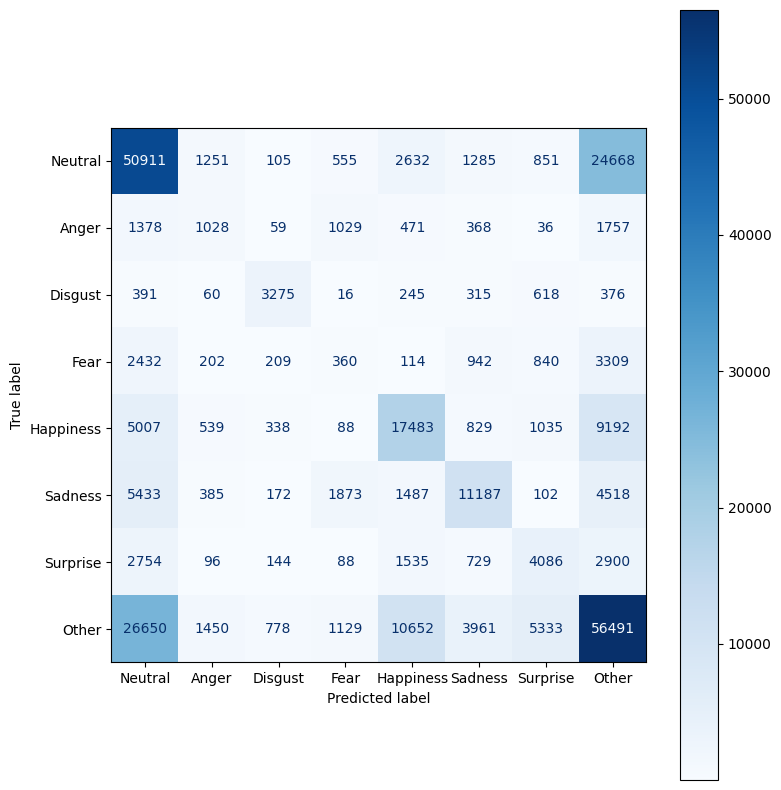

In [112]:
labels=['Neutral','Anger','Disgust','Fear','Happiness','Sadness','Surprise','Other']
IC = type('IdentityClassifier', (), {"predict": lambda i : i, "_estimator_type": "classifier"})
import matplotlib.pyplot as plt
#from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def plt_conf_matrix(y_true,y_pred,labels):
    print(y_pred.shape,y_true.shape, (y_pred==y_true).mean())

    fig, ax = plt.subplots(figsize=(8, 8))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax, cmap=plt.cm.Blues)
    
    #plot_confusion_matrix(IC, y_pred,y_true,display_labels=labels,cmap=plt.cm.Blues,ax=ax,colorbar=False,values_format='d') #,normalize='true'
    plt.tight_layout()
    plt.show()
plt_conf_matrix(y_val,y_pred,labels)

In [199]:
for w in np.linspace(0,1,11):
    print(w)
    y_ensemble=w*y_val_preds+(1-w)*y_val_expr_preds_audio
    y_pred=np.argmax(y_ensemble,axis=1)
    print('Acc:',(y_pred==y_val).mean(), 'F1:',f1_score(y_true=y_val,y_pred=y_pred, average="macro"))
    

0.0
Acc: 0.4187828839490682 F1: 0.32331301740899343
0.1
Acc: 0.4750153280196199 F1: 0.36659845823774784
0.2
Acc: 0.509649523049064 F1: 0.39359639151867404
0.30000000000000004
Acc: 0.5280645345272553 F1: 0.41224828831608357
0.4
Acc: 0.5343846691286556 F1: 0.4218740371303995
0.5
Acc: 0.5350049192249012 F1: 0.42667056854295665
0.6000000000000001
Acc: 0.5339676044087662 F1: 0.4310558217992586
0.7000000000000001
Acc: 0.5309768582550297 F1: 0.4308300071859683
0.8
Acc: 0.5255728401750959 F1: 0.42484101559956566
0.9
Acc: 0.5198658263584903 F1: 0.41871970725824703
1.0
Acc: 0.5162370068298804 F1: 0.4139844169394211


### Scores 

In [113]:
dirpath=os.path.join(DATA_DIR,'EXPR_Recognition_Challenge/Validation_Set')
num_missed=0
y_scores_all,y_val=[],[]

for filename in os.listdir(dirpath):
    fn, ext = os.path.splitext(os.path.basename(filename))
    if ext.lower()=='.txt':
        with open(os.path.join(dirpath,filename)) as f:
            lines = f.read().splitlines()
            prev_val=None
            for i,line in enumerate(lines):
                if i>0:
                    expression=int(line)
                    #if expression>=0:
                    if expression>=0:
                        imagename=fn+'/'+get_names(i)+'.jpg'
                        if imagename in filename2featuresAll:
                            scores=filename2featuresAll[imagename][1]
                            if False:
                                scores=scores[:-2]
                            y_scores_all.append(scores[AFFECTNET2MTL])
                            y_val.append(expression)
                        else:
                            num_missed+=1
y_scores_all=np.array(y_scores_all)
y_val=np.array(y_val)
print(y_scores_all.shape,y_val.shape,num_missed)

y_scores=np.argmax(y_scores_all[y_val!=7,:7],axis=1)
print('w/o Other',metric_for_Exp(y_val[y_val!=7],y_scores,7))
y_scores=np.argmax(y_scores_all,axis=1)
print('with Other:',metric_for_Exp(y_val,y_scores,8))

(280532, 8) (280532,) 3698
w/o Other (0.3831895604358208, 0.5219659023022839, [0.5942068197806105, 0.11670020120724346, 0.25647739049800905, 0.11472978584564276, 0.6221833130328868, 0.5746362248983847, 0.40339318778796884])
with Other: (0.2574527273808269, 0.3256491238076227, [0.4726642646249312, 0.0815823131737621, 0.16901307024808268, 0.08021235120899174, 0.4628094308336849, 0.47392951497931307, 0.28223668353820197, 0.03717419043964771])


embeddings:
Acc: 0.4961929476851126 F1: 0.3822393283107972
(0.3822393283107972, 0.4961929476851126, [0.5816358825689002, 0.19165239340124404, 0.4775824331003319, 0.06514293702383449, 0.4966704252920027, 0.4404618154856478, 0.27396940324652574, 0.5307993363678905])

In [66]:
def scores2probabs(x):
    e_x = np.exp(x - np.max(x))#[np.newaxis])
    e_x = e_x / e_x.sum(axis=1)[:,None]
    return e_x

In [121]:
#y_scores=np.argmax(y_scores_all[y_val!=7,:7],axis=1)
y_pred_scores=np.argmax(y_probabs_all[:,:7],axis=1)

for t in np.linspace(0,1,11):
    y_pred_all=np.argmax(y_val_preds,axis=1)
    criterion=np.array([y_p[y_s]>t for y_p,y_s in zip(y_probabs_all,y_pred_scores)])
    #criterion=y_pred_all!=7
    y_pred_all[criterion]=y_pred_scores[criterion]
    print(t,metric_for_Exp(y_val,y_pred_all,8),criterion.sum())

0.0 (0.2534210822478764, 0.3241840503044216, [0.4774101610904585, 0.0793468667255075, 0.1677580071174377, 0.08018907040384775, 0.4680883560205426, 0.4724297845358133, 0.28214641208940366, 0.0]) 280532
0.1 (0.25351284107007493, 0.32425177876320704, [0.47743606264869154, 0.0798233995584989, 0.1677580071174377, 0.08018907040384775, 0.4682577565632458, 0.47243565833644163, 0.28214641208940366, 5.6361843032267155e-05]) 280461
0.2 (0.25413527176197837, 0.3248755935151783, [0.47749917948019294, 0.08038599442255766, 0.16803366379002924, 0.08012275536017915, 0.4689019953276397, 0.47236518236742, 0.28221525096525096, 0.0035581523825575626]) 279359
0.30000000000000004 (0.26760678252133885, 0.3404317511014786, [0.4844163554060405, 0.08502671354856386, 0.1774710563035034, 0.08323497267759562, 0.4752895154731012, 0.47696470144088593, 0.28911208330765914, 0.06933886201336098]) 266289
0.4 (0.3049224282262506, 0.3868471333038655, [0.5134590645404015, 0.09886874322020765, 0.21540571428571428, 0.08802868

---------------

### Smooth validation predictions  

In [62]:
if True:
    model = MLP(1280, 8).to(device)
    if False:
        model.load_state_dict(torch.load('expr_enet0_vgaf.pt'))
        best_b=np.array([ 1.6999999, 0.86949295, 0.20041052, 0.8711935, 0.01852902, -0.08902326, 0.12363616, 2.0660875 ])
    elif True:
        model.load_state_dict(torch.load('expr_enet0_vgaf_train_val.pt'))
        best_b=np.array([ 2.348354  , -0.6153797 ,  0.7301737 ,  0.14542618,  1.7396067 , 1.3634353 ,  0.32395673,  1.9])        
    else:
        model.load_state_dict(torch.load('expr_enet0_vgaf_gamma.pt'))
        best_b=np.array([1.3, 0.56949294, 1.0004104, 2.2711935, 0.318529, 1.3109767, 0.32363614, 1.2660874])
    model.eval()

In [21]:
data_dir=os.path.join(DATA_DIR,'faces')
dirpath=os.path.join(DATA_DIR,'EXPR_Recognition_Challenge/Validation_Set')
test_videos={}
with torch.no_grad():
    for filename in tqdm(os.listdir(dirpath)):
        fn, ext = os.path.splitext(os.path.basename(filename))
        if ext.lower()=='.txt':
            X,indices,expressions,scores=[],[],[],[]
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                prev_val=None
                for i,line in enumerate(lines):
                    if i>0:
                        imagename=fn+'/'+get_names(i)+'.jpg'
                        if imagename in filename2featuresAll:
                            X.append(filename2featuresAll[imagename][0])
                            indices.append(i)
                            expressions.append(int(line))
                            scores.append(filename2featuresAll[imagename][1][AFFECTNET2MTL])
            
            logits = model(torch.tensor(np.array(X), dtype=torch.float32).to(device)).cpu()
            if True:
                probs_val = F.softmax(logits, dim=1).cpu().numpy()
                logits_adj = np.log(probs_val + 1e-12) + best_b
            else:
                logits_adj=logits.cpu().numpy()
            test_videos[fn]=(scores2probabs(logits_adj),indices,np.array(expressions),np.array(scores))
    print(len(test_videos))

  0%|          | 0/70 [00:00<?, ?it/s]

70


In [142]:
hyperparams=[(isMean,delta) for delta in [0,2,7]  for isMean in [1,0] if not (isMean==0 and delta==0)]
total_true=[]
total_preds=[[] for _ in range(len(hyperparams))]
for videoname,(y_pred_expr,indices,expressions,scores) in test_videos.items():
    for i,ind in enumerate(indices):
        if expressions[i]>=0:
            total_true.append(expressions[i])
    cur_ind=0
    preds_proba=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds_proba.append(y_pred_expr[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds_proba.append(y_pred_expr[cur_ind])
            else:
                w=(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_expr[cur_ind-1]+(1-w)*y_pred_expr[cur_ind]
                preds_proba.append(pred)
    
    preds_proba=np.array(preds_proba)
    for hInd,(isMean,delta) in enumerate(hyperparams):
        preds=[]
        for i in range(len(preds_proba)):
            i1=max(i-delta,0)
            if isMean:
                proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
            else:
                proba=np.median(preds_proba[i1:i+delta+1],axis=0)
            preds.append(np.argmax(proba))
        for i,ind in enumerate(indices):
            if expressions[i]>=0:
                total_preds[hInd].append(preds[ind-1])

total_true=np.array(total_true)
for hInd,(isMean,delta) in enumerate(hyperparams):
    preds=np.array(total_preds[hInd])
    print('mean' if isMean else 'median',delta,'Acc:',(preds==total_true).mean(), 'F1:',f1_score(y_true=total_true,y_pred=preds, average="macro"))

mean 0 Acc: 0.5162370068298804 F1: 0.4139844169394211
mean 2 Acc: 0.5252555858155219 F1: 0.4207785049414764
median 2 Acc: 0.5246175124406485 F1: 0.4207518925421263
mean 7 Acc: 0.534088802703435 F1: 0.42818854441238174
median 7 Acc: 0.5337145138522521 F1: 0.42831678516823257


In [143]:
#deltas=[0,1,5,7,15]
deltas=[0,5,15,25,50,100,200,500]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]
for videoname,(y_pred_expr,indices,expressions,scores) in test_videos.items():
    for i,ind in enumerate(indices):
        if expressions[i]>=0:
            total_true.append(expressions[i])
    cur_ind=0
    preds_proba=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds_proba.append(y_pred_expr[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds_proba.append(y_pred_expr[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_expr[cur_ind-1]+(1-w)*y_pred_expr[cur_ind]
                preds_proba.append(pred)
    
    preds_proba=np.array(preds_proba)
    for hInd,delta in enumerate(deltas):
        preds=[]
        for i in range(len(preds_proba)):
            i1=max(i-delta,0)
            proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
            preds.append(np.argmax(proba))
        for i,ind in enumerate(indices):
            if expressions[i]>=0:
                total_preds[hInd].append(preds[ind-1])

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    print(delta,'Acc:',(preds==total_true).mean(), 'F1:',f1_score(y_true=total_true,y_pred=preds, average="macro"))

0 Acc: 0.5162370068298804 F1: 0.4139844169394211
5 Acc: 0.5314545221222534 F1: 0.42583440850362664
15 Acc: 0.5440484508006217 F1: 0.43842627897235054
25 Acc: 0.5484721885560293 F1: 0.4430968201579329
50 Acc: 0.5541613790940071 F1: 0.44851347308597644
100 Acc: 0.5513239131364693 F1: 0.43908740496425325
200 Acc: 0.5482297919666919 F1: 0.4373736632297445
500 Acc: 0.5474420030513453 F1: 0.4271887355015417


0 Acc: 0.5162370068298804 F1: 0.4139844169394211
5 Acc: 0.5314545221222534 F1: 0.42583440850362664
15 Acc: 0.5440484508006217 F1: 0.43842627897235054
25 Acc: 0.5484721885560293 F1: 0.4430968201579329
50 Acc: 0.5541613790940071 F1: 0.44851347308597644
100 Acc: 0.5513239131364693 F1: 0.43908740496425325
200 Acc: 0.5482297919666919 F1: 0.4373736632297445
500 Acc: 0.5474420030513453 F1: 0.4271887355015417

In [38]:
if False:
    with open('expr_val_test_videos.pickle', 'wb') as handle:
        pickle.dump(test_videos, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open('expr_val_test_videos.pickle', 'rb') as handle:
        test_videos=pickle.load(handle)
print(len(test_videos))

70


In [144]:
deltas=[0,5,15,25,50,100,200,500]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]
for videoname,(y_pred_expr,indices,expressions,scores) in test_videos.items():
    for i,ind in enumerate(indices):
        if expressions[i]>=0:
            total_true.append(expressions[i])

    pretrained_scores_probabs=scores2probabs(scores)
    cur_ind=0
    preds_proba,pretrained_preds_proba=[],[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds_proba.append(y_pred_expr[cur_ind])
            pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds_proba.append(y_pred_expr[cur_ind])
                pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_expr[cur_ind-1]+(1-w)*y_pred_expr[cur_ind]
                preds_proba.append(pred)
                
                s=w*pretrained_scores_probabs[cur_ind-1]+(1-w)*pretrained_scores_probabs[cur_ind]
                pretrained_preds_proba.append(s)
    
    preds_proba=np.array(preds_proba)
    pretrained_preds_proba=np.array(pretrained_preds_proba)
    
    for hInd,delta in enumerate(deltas):
        preds=[]
        for i in range(len(preds_proba)):
            i1=max(i-delta,0)
            proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
            pred=np.argmax(proba)
            
            pretrained_proba=np.mean(pretrained_preds_proba[i1:i+delta+1],axis=0)
            pretrained_pred=np.argmax(pretrained_proba[:7])
            if pretrained_proba[pretrained_pred]>0.8:
                pred=pretrained_pred
            
            preds.append(pred)
        for i,ind in enumerate(indices):
            if expressions[i]>=0:
                total_preds[hInd].append(preds[ind-1])

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    print(delta,'Acc:',(preds==total_true).mean(), 'F1:',f1_score(y_true=total_true,y_pred=preds, average="macro"))

0 Acc: 0.5169641965978926 F1: 0.4201447546953748
5 Acc: 0.5372934282007044 F1: 0.43857823392311296
15 Acc: 0.550946059629561 F1: 0.4523463454854766
25 Acc: 0.5549705559437069 F1: 0.4562907420808369
50 Acc: 0.5568598234782485 F1: 0.4579055473413275
100 Acc: 0.550589594057006 F1: 0.4450759762616241
200 Acc: 0.5445653258808264 F1: 0.4359715268880606
500 Acc: 0.5421377953317269 F1: 0.42389430122578675


In [198]:
thresholds=np.linspace(0,1,11)

delta=50
total_true=[]
total_preds=[[] for _ in range(len(thresholds))]
for videoname,(y_pred_expr,indices,expressions,scores) in test_videos.items():
    for i,ind in enumerate(indices):
        if expressions[i]>=0:
            total_true.append(expressions[i])

    pretrained_scores_probabs=scores2probabs(scores)
    cur_ind=0
    preds_proba,pretrained_preds_proba=[],[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds_proba.append(y_pred_expr[cur_ind])
            pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds_proba.append(y_pred_expr[cur_ind])
                pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_expr[cur_ind-1]+(1-w)*y_pred_expr[cur_ind]
                preds_proba.append(pred)
                
                s=w*pretrained_scores_probabs[cur_ind-1]+(1-w)*pretrained_scores_probabs[cur_ind]
                pretrained_preds_proba.append(s)
    
    preds_proba=np.array(preds_proba)
    pretrained_preds_proba=np.array(pretrained_preds_proba)
    
    for hInd,t in enumerate(thresholds):
        preds=[]
        for i in range(len(preds_proba)):
            i1=max(i-delta,0)
            proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
            pred=np.argmax(proba)
            
            pretrained_proba=np.mean(pretrained_preds_proba[i1:i+delta+1],axis=0)
            pretrained_pred=np.argmax(pretrained_proba[:7])
            if pretrained_proba[pretrained_pred]>t:
                pred=pretrained_pred
            
            preds.append(pred)
        for i,ind in enumerate(indices):
            if expressions[i]>=0:
                total_preds[hInd].append(preds[ind-1])

total_true=np.array(total_true)
for hInd,t in enumerate(thresholds):
    preds=np.array(total_preds[hInd])
    print(t,'Acc:',(preds==total_true).mean(), 'F1:',f1_score(y_true=total_true,y_pred=preds, average="macro"))

0.0 Acc: 0.3547901843639941 F1: 0.2768972468723374
0.1 Acc: 0.3547901843639941 F1: 0.2768972468723374
0.2 Acc: 0.35554589137781073 F1: 0.27757453979923763
0.30000000000000004 Acc: 0.39563400966734635 F1: 0.3117207730563307
0.4 Acc: 0.4673976587341195 F1: 0.36873604573637997
0.5 Acc: 0.5195450073431908 F1: 0.4158468890075469
0.6000000000000001 Acc: 0.5430432178860166 F1: 0.44370284057004244
0.7000000000000001 Acc: 0.5521901244777779 F1: 0.4549825263949689
0.8 Acc: 0.5568598234782485 F1: 0.4579055473413275
0.9 Acc: 0.5560755992186275 F1: 0.45269708387999585
1.0 Acc: 0.5541613790940071 F1: 0.44851347308597644


------------------

### Audio 

In [176]:
modelAudio = MLP(768, 8).to(device)
modelAudio.load_state_dict(torch.load('expr_wav2vec_gamma.pt'))
best_b=np.array([1.6, 1.0520328, 0.29831293, 2.5848334, 1.1163865, 1.5038269, 0.62743944, 1.1590843 ])
modelAudio.eval()

MLP(
  (net): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=8, bias=True)
  )
)

In [228]:
data_dir=os.path.join(DATA_DIR,'faces')
dirpath=os.path.join(DATA_DIR,'EXPR_Recognition_Challenge/Validation_Set')
test_audios={}
with torch.no_grad():
    for filename in tqdm(os.listdir(dirpath)):
        fn, ext = os.path.splitext(os.path.basename(filename))
        fn_short=fn
        if fn.endswith('_left'):
            fn_short=fn[:-5]
        elif fn.endswith('_right'):
            fn_short=fn[:-6]
        if ext.lower()=='.txt':
            X,indices,expressions,scores=[],[],[],[]
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                prev_val=None
                for i,line in enumerate(lines):
                    if i>0:
                        imagename=fn+'/'+get_names(i)+'.jpg'
                        imagename_short=fn_short+'/'+get_names(i)+'.jpg'
                        imagename=fn+'/'+get_names(i)+'.jpg'
                        has_image=imagename_short in filename2audio_features
                        has_frame=os.path.exists(os.path.join(DATA_DIR,'cropped',imagename))
                        if has_image:
                            has_image=has_frame
                        elif has_frame:
                            #print(imagename,imagename in filename2audio_features,imagename in filename2featuresAll)
                            imagename_short=fn_short+'/'+get_names(i-1)+'.jpg'
                            has_image=imagename_short in filename2audio_features
                        if has_image:
                            X.append(filename2audio_features[imagename_short])
                            indices.append(i)
                            expressions.append(int(line))
                            scores.append(filename2featuresAll[imagename][1][AFFECTNET2MTL])
            logits = modelAudio(torch.tensor(np.array(X), dtype=torch.float32).to(device)).cpu()
            probs_val = F.softmax(logits, dim=1).cpu().numpy()
            logits_adj = np.log(probs_val + 1e-12) + best_b
            #preds_adj = np.argmax(logits_adj, axis=1)
            test_audios[fn]=(scores2probabs(logits_adj),indices,np.array(expressions),np.array(scores))
    print(len(test_audios))


100%|█████████████████████████████████████████████████████████████████| 70/70 [00:12<00:00,  5.38it/s]

70


In [39]:
if False:
    with open('expr_val_test_audios.pickle', 'wb') as handle:
        pickle.dump(test_audios, handle, protocol=pickle.HIGHEST_PROTOCOL)
else:
    with open('expr_val_test_audios.pickle', 'rb') as handle:
        test_audios=pickle.load(handle)
print(len(test_audios))

70


In [178]:
#deltas=[0,1,5,7,15]
deltas=[0,5,15,25,50,100,200,500]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]
for videoname,(y_pred_expr,indices,expressions,scores) in test_audios.items():
    for i,ind in enumerate(indices):
        if expressions[i]>=0:
            total_true.append(expressions[i])
    cur_ind=0
    preds_proba=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds_proba.append(y_pred_expr[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds_proba.append(y_pred_expr[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_expr[cur_ind-1]+(1-w)*y_pred_expr[cur_ind]
                preds_proba.append(pred)
    
    preds_proba=np.array(preds_proba)
    for hInd,delta in enumerate(deltas):
        preds=[]
        for i in range(len(preds_proba)):
            i1=max(i-delta,0)
            proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
            preds.append(np.argmax(proba))
        for i,ind in enumerate(indices):
            if expressions[i]>=0:
                total_preds[hInd].append(preds[ind-1])

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    print(delta,'Acc:',(preds==total_true).mean(), 'F1:',f1_score(y_true=total_true,y_pred=preds, average="macro"))

0 Acc: 0.4187828839490682 F1: 0.32331301740899343
5 Acc: 0.4860194202443928 F1: 0.3690387675455183
15 Acc: 0.5044629489683886 F1: 0.3796274795908978
25 Acc: 0.510155704162092 F1: 0.3845055413212025
50 Acc: 0.5174026492521352 F1: 0.3875151092391821
100 Acc: 0.5185041278713302 F1: 0.3873461328020498
200 Acc: 0.5188570287881596 F1: 0.3882310616191418
500 Acc: 0.5228102319877946 F1: 0.38824828642039405


In [172]:
#Ensemble
deltas=[0,5,15,25,50,100,200,500]
for weight in np.linspace(0,1,11):
    total_true=[]
    total_preds=[[] for _ in range(len(deltas))]
    for videoname,(y_pred_expr,indices,expressions,_) in test_videos.items():
        y_pred_expr_audio,_,_,_=test_audios[videoname]
        for i,ind in enumerate(indices):
            if expressions[i]>=0:
                total_true.append(expressions[i])
        cur_ind=0
        preds_proba=[]
        y_ensemble=weight*y_pred_expr + (1-weight)*y_pred_expr_audio
        for i in range(indices[-1]):
            if indices[cur_ind]-1==i:
                cur_pred=y_ensemble[cur_ind]
                preds_proba.append(cur_pred)
                cur_ind+=1
            else:
                if cur_ind==0:
                    preds_proba.append(y_ensemble[cur_ind])
                else:
                    w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                    pred=w*y_ensemble[cur_ind-1]+(1-w)*y_ensemble[cur_ind]
                    preds_proba.append(pred)

        preds_proba=np.array(preds_proba)
        for hInd,delta in enumerate(deltas):
            preds=[]
            for i in range(len(preds_proba)):
                i1=max(i-delta,0)
                proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
                preds.append(np.argmax(proba))
            for i,ind in enumerate(indices):
                if expressions[i]>=0:
                    total_preds[hInd].append(preds[ind-1])

    total_true=np.array(total_true)
    print(weight)
    for hInd,delta in enumerate(deltas):
        preds=np.array(total_preds[hInd])
        print(delta,'Acc:',(preds==total_true).mean(), 'F1:',f1_score(y_true=total_true,y_pred=preds, average="macro"))
    print()

0.0
0 Acc: 0.4187828839490682 F1: 0.32331301740899343
5 Acc: 0.4860194202443928 F1: 0.3690387675455183
15 Acc: 0.5044629489683886 F1: 0.3796274795908978
25 Acc: 0.510155704162092 F1: 0.3845055413212025
50 Acc: 0.5174026492521352 F1: 0.3875151092391821
100 Acc: 0.5185041278713302 F1: 0.3873461328020498
200 Acc: 0.5188570287881596 F1: 0.3882310616191418
500 Acc: 0.5228102319877946 F1: 0.38824828642039405

0.1
0 Acc: 0.44386380163403816 F1: 0.3418136970007542
5 Acc: 0.5125297648753083 F1: 0.39062674217683047
15 Acc: 0.5280645345272553 F1: 0.401315527543523
25 Acc: 0.5338250181797441 F1: 0.40571621126279744
50 Acc: 0.5408331313361755 F1: 0.409442161670089
100 Acc: 0.541471204711049 F1: 0.4093647898071686
200 Acc: 0.5445795845037287 F1: 0.4096671062694732
500 Acc: 0.5491245205538049 F1: 0.4090804667170133

0.2
0 Acc: 0.473065461337744 F1: 0.3657870202495541
5 Acc: 0.5337537250652332 F1: 0.4123383176770391
15 Acc: 0.5441946016853693 F1: 0.4185852663063837
25 Acc: 0.54792679623002 F1: 0.42104

In [233]:
#Ensemble
#deltas=[0,5,15,25,50,100,200,500]
thresholds=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]#np.linspace(0,1,11)
delta=50
for weight in np.linspace(0,1,11):
    total_true=[]
    total_preds=[[] for _ in range(len(thresholds))]
    for videoname,(y_pred_expr,indices,expressions,scores) in test_videos.items():
        for i,ind in enumerate(indices):
            if expressions[i]>=0:
                total_true.append(expressions[i])
        
        y_pred_expr_audio,_,_,_=test_audios[videoname]
        y_ensemble=weight*y_pred_expr + (1-weight)*y_pred_expr_audio
        pretrained_scores_probabs=scores2probabs(scores)
        cur_ind=0
        preds_proba,pretrained_preds_proba=[],[]
        for i in range(indices[-1]):
            if indices[cur_ind]-1==i:
                preds_proba.append(y_ensemble[cur_ind])
                pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
                cur_ind+=1
            else:
                if cur_ind==0:
                    preds_proba.append(y_ensemble[cur_ind])
                    pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
                else:
                    w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                    pred=w*y_ensemble[cur_ind-1]+(1-w)*y_ensemble[cur_ind]
                    preds_proba.append(pred)

                    s=w*pretrained_scores_probabs[cur_ind-1]+(1-w)*pretrained_scores_probabs[cur_ind]
                    pretrained_preds_proba.append(s)

        preds_proba=np.array(preds_proba)
        pretrained_preds_proba=np.array(pretrained_preds_proba)

        for hInd,t in enumerate(thresholds):
            preds=[]
            for i in range(len(preds_proba)):
                i1=max(i-delta,0)
                proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
                pred=np.argmax(proba)

                pretrained_proba=np.mean(pretrained_preds_proba[i1:i+delta+1],axis=0)
                pretrained_pred=np.argmax(pretrained_proba[:7])
                if pretrained_proba[pretrained_pred]>t:
                    pred=pretrained_pred
                preds.append(pred)

            for i,ind in enumerate(indices):
                if expressions[i]>=0:
                    total_preds[hInd].append(preds[ind-1])

    total_true=np.array(total_true)
    print(weight)
    for hInd,t in enumerate(thresholds):
        preds=np.array(total_preds[hInd])
        print(t,'Acc:',(preds==total_true).mean(), 'F1:',f1_score(y_true=total_true,y_pred=preds, average="macro"))
    print()        
        

0.0
0.5 Acc: 0.5340745440805327 F1: 0.4194505169106644
0.6 Acc: 0.5524040038213109 F1: 0.43844282562751524
0.7 Acc: 0.5505717707783783 F1: 0.43885790300992733
0.8 Acc: 0.5412181141545349 F1: 0.42987467794652817
0.9 Acc: 0.526720659318723 F1: 0.4063004004800015
1.0 Acc: 0.5174026492521352 F1: 0.3875151092391821

0.1
0.5 Acc: 0.542864985099739 F1: 0.42329157510760024
0.6 Acc: 0.5644311522393167 F1: 0.44640172746483253
0.7 Acc: 0.5666875793135899 F1: 0.45064930180583174
0.8 Acc: 0.5595404445838621 F1: 0.44408520619879394
0.9 Acc: 0.5468787874467084 F1: 0.4228386838097101
1.0 Acc: 0.5408331313361755 F1: 0.409442161670089

0.2
0.5 Acc: 0.5476380591162505 F1: 0.4252843956679926
0.6 Acc: 0.5695571271726577 F1: 0.44943091008426966
0.7 Acc: 0.5740307701082229 F1: 0.4567376009884959
0.8 Acc: 0.5681740407511443 F1: 0.45198301999512447
0.9 Acc: 0.5569917157400939 F1: 0.4326587859804578
1.0 Acc: 0.5521509132647969 F1: 0.4213750935557181

0.30000000000000004
0.5 Acc: 0.5454315372221351 F1: 0.4251252

### Save test results 

In [64]:
with open(os.path.join(DATA_DIR,'test_set_examples/CVPR_6th_ABAW_Expr_test_set_example.txt'),'r') as f:
    test_set_sample=f.read().splitlines()
print(len(test_set_sample),test_set_sample[:5])

test_set_videos={}
for s in test_set_sample[1:]:
    videoname,img_name=s[:-2].split('/')
    if videoname not in test_set_videos:
        test_set_videos[videoname]=[]
    test_set_videos[videoname].append(img_name)
    
print(len(test_set_videos))

1022656 ['image_location,Neutral,Anger,Disgust,Fear,Happiness,Sadness,Surprise,Other', '14-30-1920x1080/00001.jpg,0', '14-30-1920x1080/00002.jpg,0', '14-30-1920x1080/00003.jpg,0', '14-30-1920x1080/00004.jpg,0']
228


In [60]:
if True:
    model = MLP(1280, 8).to(device)
    if False:
        model.load_state_dict(torch.load('expr_enet0_vgaf.pt'))
        best_b=np.array([ 1.6999999, 0.86949295, 0.20041052, 0.8711935, 0.01852902, -0.08902326, 0.12363616, 2.0660875 ])
    elif True:
        model.load_state_dict(torch.load('expr_enet0_vgaf_train_val.pt'))
        best_b=np.array([ 2.348354  , -0.6153797 ,  0.7301737 ,  0.14542618,  1.7396067 , 1.3634353 ,  0.32395673,  1.9])        
    else:
        model.load_state_dict(torch.load('expr_enet0_vgaf_gamma.pt'))
        best_b=np.array([1.3, 0.56949294, 1.0004104, 2.2711935, 0.318529, 1.3109767, 0.32363614, 1.2660874])
    model.eval()


In [67]:
test_videos={}
test_videos_num_frames={}
with torch.no_grad():
    for videoname,img_files in tqdm(test_set_videos.items()):
        X,indices,filenames,scores=[],[],[],[]
        num_present=num_missed=0
        for img_name in img_files:
            k=videoname+'/'+img_name
            if k in filename2featuresAll:
                X.append(filename2featuresAll[k][0])
                indices.append(int(img_name[:-4]))
                filenames.append(k)
                scores.append(filename2featuresAll[k][1][AFFECTNET2MTL])
                num_present+=1
            else:
                num_missed+=1
        
        logits = model(torch.tensor(np.array(X), dtype=torch.float32).to(device)).cpu()
        if False:
            probs_val = F.softmax(logits, dim=1).cpu().numpy()
            logits_adj = np.log(probs_val + 1e-12) + best_b
        else:
            logits_adj=logits.cpu().numpy()
        test_videos[videoname]=(scores2probabs(logits_adj),indices,filenames,np.array(scores))
        test_videos_num_frames[videoname]=(num_present,num_missed)
    print(len(test_videos))

  0%|          | 0/228 [00:00<?, ?it/s]

228


In [255]:
if False:
    modelAudio = MLP(768, 8).to(device)
    modelAudio.load_state_dict(torch.load('expr_wav2vec_gamma.pt'))
    best_b=np.array([1.6, 1.0520328, 0.29831293, 2.5848334, 1.1163865, 1.5038269, 0.62743944, 1.1590843 ])
    modelAudio.eval()
test_audios={}
test_audios_num_frames={}
with torch.no_grad():
    for videoname,img_files in tqdm(test_set_videos.items()):
        X,indices,filenames,scores=[],[],[],[]
        num_present=num_missed=0
        fn_short=videoname
        if videoname.endswith('_left'):
            fn_short=videoname[:-5]
        elif videoname.endswith('_right'):
            fn_short=videoname[:-6]
        for img_name in img_files:
            k=fn_short+'/'+img_name
            if k in filename2audio_features:
                X.append(filename2audio_features[k])
                indices.append(int(img_name[:-4]))
                filenames.append(k)
                num_present+=1
            else:
                num_missed+=1
        
        logits = modelAudio(torch.tensor(np.array(X), dtype=torch.float32).to(device)).cpu()
        probs_val = F.softmax(logits, dim=1).cpu().numpy()
        logits_adj = np.log(probs_val + 1e-12) + best_b
        #preds_adj = np.argmax(logits_adj, axis=1)
        test_audios[videoname]=(scores2probabs(logits_adj),indices,filenames,np.array(scores))
        test_audios_num_frames[videoname]=(num_present,num_missed)
    print(len(test_audios))

100%|███████████████████████████████████████████████████████████████| 228/228 [00:02<00:00, 97.16it/s]

228


In [68]:
delta=50 # 0 2 4 7
OUTPUT_DIR=DATA_DIR+'/test_results/EXPR'
if not os.path.exists(OUTPUT_DIR):
    os.mkdir(OUTPUT_DIR)
print(OUTPUT_DIR)

/home/HDD6TB/datasets/emotions/ABAW/ABAW_10/ABAW_Annotations/test_results/EXPR


In [69]:
#for t in np.linspace(0.5,1,6):
#for t in [0.6, 0.7, 0.8, 0.9]:
for t in [0.8, 0.9]:
    num_changed_frames,num_frames=0,0
    #with open(os.path.join(OUTPUT_DIR,'predictions_'+str(t)+'_train_val.txt'), 'w') as f:
    with open(os.path.join(OUTPUT_DIR,'predictions_no_gla_'+str(t)+'_train_val.txt'), 'w') as f:
        f.write(test_set_sample[0]+'\n')
        for videoname,(y_pred_expr,indices,filenames,scores) in test_videos.items():
            pretrained_scores_probabs=scores2probabs(scores)
            cur_ind=0
            preds_proba,pretrained_preds_proba=[],[]
            for i in range(indices[-1]):
                if indices[cur_ind]-1==i:
                    preds_proba.append(y_pred_expr[cur_ind])
                    pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
                    cur_ind+=1
                else:
                    if cur_ind==0:
                        preds_proba.append(y_pred_expr[cur_ind])
                        pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
                    else:
                        w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                        pred=w*y_pred_expr[cur_ind-1]+(1-w)*y_pred_expr[cur_ind]
                        preds_proba.append(pred)

                        s=w*pretrained_scores_probabs[cur_ind-1]+(1-w)*pretrained_scores_probabs[cur_ind]
                        pretrained_preds_proba.append(s)

            pred=y_pred_expr[cur_ind-1]
            pretrained_pred=pretrained_scores_probabs[cur_ind-1]
            for _ in range(indices[-1],len(test_set_videos[videoname])):
                preds_proba.append(pred)
                pretrained_preds_proba.append(pretrained_pred)

            preds_proba=np.array(preds_proba)
            pretrained_preds_proba=np.array(pretrained_preds_proba)
            for i,img_name in enumerate(test_set_videos[videoname]):
                i1=max(i-delta,0)
                proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
                pred=np.argmax(proba)

                pretrained_proba=np.mean(pretrained_preds_proba[i1:i+delta+1],axis=0)
                pretrained_pred=np.argmax(pretrained_proba[:7])
                if pretrained_proba[pretrained_pred]>t:
                    if pred!=pretrained_pred:
                        num_changed_frames+=1
                    pred=pretrained_pred
                num_frames+=1
                f.write(videoname+'/'+img_name+','+str(pred)+'\n')
    print(num_changed_frames,num_frames)

26633 1022655
9520 1022655


In [269]:
#weight=0.7
for weight in [0.5, 0.6, 0.7]:
    for t in [0.7, 0.8]:
        num_changed_frames,num_frames=0,0
        with open(os.path.join(OUTPUT_DIR,'av_predictions_'+str(weight)+'_'+str(t)+'_train_val_wav2vec.txt'), 'w') as f:
        #with open(os.path.join(OUTPUT_DIR,'av_predictions_'+str(weight)+'_'+str(t)+'_wav2vec.txt'), 'w') as f:
            f.write(test_set_sample[0]+'\n')
            for videoname,(y_pred_expr,indices,filenames,scores) in test_videos.items():
                y_pred_expr_audio,indices_audio,filenames_audio,_=test_audios[videoname]

                pretrained_scores_probabs=scores2probabs(scores)
                cur_ind=0
                preds_proba,pretrained_preds_proba=[],[]
                for i in range(indices[-1]):
                    if indices[cur_ind]-1==i:
                        preds_proba.append(y_pred_expr[cur_ind])
                        pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
                        cur_ind+=1
                    else:
                        if cur_ind==0:
                            preds_proba.append(y_pred_expr[cur_ind])
                            pretrained_preds_proba.append(pretrained_scores_probabs[cur_ind])
                        else:
                            w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                            pred=w*y_pred_expr[cur_ind-1]+(1-w)*y_pred_expr[cur_ind]
                            preds_proba.append(pred)

                            s=w*pretrained_scores_probabs[cur_ind-1]+(1-w)*pretrained_scores_probabs[cur_ind]
                            pretrained_preds_proba.append(s)

                pred=y_pred_expr[cur_ind-1]
                pretrained_pred=pretrained_scores_probabs[cur_ind-1]
                for _ in range(indices[-1],len(test_set_videos[videoname])):
                    preds_proba.append(pred)
                    pretrained_preds_proba.append(pretrained_pred)

                preds_proba=np.array(preds_proba)
                preds_proba=weight*preds_proba+(1-weight)*y_pred_expr_audio
                pretrained_preds_proba=np.array(pretrained_preds_proba)
                for i,img_name in enumerate(test_set_videos[videoname]):
                    i1=max(i-delta,0)
                    proba=np.mean(preds_proba[i1:i+delta+1],axis=0)
                    pred=np.argmax(proba)

                    pretrained_proba=np.mean(pretrained_preds_proba[i1:i+delta+1],axis=0)
                    pretrained_pred=np.argmax(pretrained_proba[:7])
                    if pretrained_proba[pretrained_pred]>t:
                        if pred!=pretrained_pred:
                            num_changed_frames+=1
                        pred=pretrained_pred
                    num_frames+=1
                    f.write(videoname+'/'+img_name+','+str(pred)+'\n')
        print(weight,t,num_changed_frames,num_frames)

0.5 0.7 84030 1022655
0.5 0.8 37869 1022655
0.6 0.7 77183 1022655
0.6 0.8 34114 1022655
0.7 0.7 72891 1022655
0.7 0.8 31738 1022655


# Valence-arousal

In [14]:
def get_image2VA(dirname):
    dirpath=os.path.join(DATA_DIR,'VA_Estimation_Challenge/',dirname)
    num_missed=0
    X,y=[],[]
    for filename in os.listdir(dirpath):
        fn, ext = os.path.splitext(os.path.basename(filename))
        if ext.lower()=='.txt':
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                for i,line in enumerate(lines):
                    if i>0:
                        splitted_line=line.split(',')
                        valence=float(splitted_line[0])
                        arousal=float(splitted_line[1])
                        if valence>=-1 and arousal>=-1:
                            imagename=fn+'/'+get_names(i)+'.jpg'
                            if imagename in filename2featuresAll:
                                X.append(filename2featuresAll[imagename][1])
                                #X.append(filename2featuresAll[imagename][0])
                                y.append((valence,arousal))
                            else:
                                num_missed+=1
    X=np.array(X)
    y=np.array(y)
    print(X.shape,y.shape,num_missed)
    return X,y

X_train,y_train=get_image2VA('Train_Set')
X_val,y_val=get_image2VA('Validation_Set')
TRAIN_VAL=False

(1653710, 512) (1653710, 2) 26147
(376323, 512) (376323, 2) 5698


In [41]:
def get_image2VA_libre(dirname):
    dirpath=os.path.join(DATA_DIR,'VA_Estimation_Challenge/',dirname)
    num_missed=0
    X,y=[],[]
    for filename in tqdm(os.listdir(dirpath)):
        fn, ext = os.path.splitext(os.path.basename(filename))
        if ext.lower()=='.txt':
            detected_aus, au_intensities, facial_expression, expr_logits=video2libreface_features[fn]
            frames=sorted(os.listdir(os.path.join(DATA_DIR,'cropped',fn)))
            frame2ind={frame:ind for ind,frame in enumerate(frames)}
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                for i,line in enumerate(lines):
                    if i>0:
                        splitted_line=line.split(',')
                        valence=float(splitted_line[0])
                        arousal=float(splitted_line[1])
                        if valence>=-1 and arousal>=-1:
                            imagename=get_names(i)+'.jpg'
                            if imagename in frame2ind and frame2ind[imagename]<len(expr_logits):
                                X.append(expr_logits[frame2ind[imagename]])
                                y.append((valence,arousal))
                            else:
                                num_missed+=1
    X=np.array(X)
    y=np.array(y)
    print(X.shape,y.shape,num_missed)
    return X,y

X_train,y_train=get_image2VA_libre('Train_Set')
X_val,y_val=get_image2VA_libre('Validation_Set')
TRAIN_VAL=False

  0%|          | 0/357 [00:00<?, ?it/s]

(1653703, 8) (1653703, 2) 26154


  0%|          | 0/76 [00:00<?, ?it/s]

(376317, 8) (376317, 2) 5704


In [97]:
if True:
    TRAIN_VAL=True
    X_train=np.concatenate((X_train,X_val))
    y_train=np.concatenate((y_train,y_val))
    print(X_train.shape,y_train.shape)

(2030033, 10) (2030033, 2)


In [15]:
def CCC_numpy(y_true, y_pred):
    '''Reference numpy implementation of Lin's Concordance correlation coefficient'''
    s_xy = np.cov([y_true, y_pred], dtype=np.float64)[0,1]
    x_m = np.mean(y_true, dtype=np.float64)
    y_m = np.mean(y_pred, dtype=np.float64)
    s_x_sq = np.var(y_true, dtype=np.float64)
    s_y_sq = np.var(y_pred, dtype=np.float64)
    ccc = (2.0*s_xy) / (s_x_sq + s_y_sq + (x_m-y_m)**2 + 1e-12)
    return ccc


def metric_for_VA(gt_V,gt_A,pred_V,pred_A):
    ccc_V,ccc_A = CCC_numpy(gt_V,pred_V),CCC_numpy(gt_A,pred_A)
    return ccc_V,ccc_A, 0.5*(ccc_V+ccc_A)


# Torch versions (used in training)
def CCC_torch(y_true, y_pred, eps=1e-8):
    # y_true, y_pred: 1D tensors
    vx = y_true - torch.mean(y_true)
    vy = y_pred - torch.mean(y_pred)
    s_xy = torch.mean(vx * vy)
    x_m = torch.mean(y_true)
    y_m = torch.mean(y_pred)
    s_x_sq = torch.var(y_true, unbiased=False)
    s_y_sq = torch.var(y_pred, unbiased=False)
    ccc = (2.0 * s_xy) / (s_x_sq + s_y_sq + (x_m - y_m)**2 + eps)
    return ccc

class CCC_VA_Loss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        # expects shape [batch, 2]
        ccc_v = CCC_torch(y_true[:,0], y_pred[:,0])
        ccc_a = CCC_torch(y_true[:,1], y_pred[:,1])
        return 1.0 - 0.5 * (ccc_v + ccc_a)

# -------------------------
# Helper print functions (to mimic original tf.py)
# -------------------------
def print_ccc_for_val_preds(y_val_preds, y_val):
    gt_V=y_val[:,0]
    gt_A=y_val[:,1]
    pred_V=y_val_preds[:,0]
    pred_A=y_val_preds[:,1]
    print(metric_for_VA(gt_V,gt_A,pred_V,pred_A))
    print(CCC_numpy(gt_V,pred_V),CCC_numpy(gt_A,pred_A))

@torch.no_grad()
def predict_numpy(model, X_np, device):
    model.eval()
    X = torch.from_numpy(X_np).float().to(device)
    preds = model(X).cpu().numpy()
    return preds

In [33]:
# -------------------------
# Model (1-layer Dense + tanh) matching TF's Dense(2, activation='tanh')
# -------------------------
class SimpleDenseTanh(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, 2)
        self.act = nn.Tanh()

    def forward(self, x):
        return self.act(self.fc(x))

class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)  # logits; apply sigmoid later for predictions

# -------------------------
# Training loop (mirrors tf.fit)
# -------------------------
def train_loop(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, save_best):
    for epoch in range(num_epochs):
        model.train()
        train_losses = 0.0
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            train_losses += loss.item() * xb.size(0)
        train_loss = train_losses / len(train_loader.dataset)

        model.eval()
        val_losses = 0.0
        val_ccc = 0.0
        ind=0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_losses += loss.item() * xb.size(0)

                yb_np=yb.cpu().numpy()
                preds_np=preds.cpu().numpy()
                gt_V=yb_np[:,0]
                gt_A=yb_np[:,1]
                pred_V=preds_np[:,0]
                pred_A=preds_np[:,1]
                _,_,ccc_avg=metric_for_VA(gt_V,gt_A,pred_V,pred_A)
                val_ccc+=ccc_avg
                ind+=1
                
            val_ccc/=ind
            
            all_features, all_labels = val_loader.dataset.tensors
            all_labels=all_labels.cpu().numpy()
            preds = mlpModel(all_features.to(device)).cpu().numpy()
            gt_V=all_labels[:,0]
            gt_A=all_labels[:,1]
            pred_V=preds[:,0]
            pred_A=preds[:,1]
            _,_,val_ccc_avg=metric_for_VA(gt_V,gt_A,pred_V,pred_A)
            
            val_loss = val_losses / len(val_loader.dataset)

        # step save best
        save_best.step(val_ccc_avg, model)

        print(f"Epoch {epoch}: train_loss={train_loss:.6f}, val_loss={val_loss:.6f}, val_ccc_avg={val_ccc_avg:.6f}, val_ccc={val_ccc:.6f}")

In [17]:
batch_size = 1024 #512 #4096 #
lr = 1e-3

# Convert to torch tensors
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float()
X_val_t   = torch.from_numpy(X_val).float()
y_val_t   = torch.from_numpy(y_val).float()

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[1]
print(input_dim)

512


In [21]:
class CombinedLoss(nn.Module):
    def __init__(self, alpha=1.0, beta=0.5):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.mse = nn.MSELoss()

    def forward(self, preds, y):
        # preds, y: shape [batch,2]
        ccc_v = CCC_torch(y[:,0], preds[:,0])
        ccc_a = CCC_torch(y[:,1], preds[:,1])
        ccc_loss = 1.0 - 0.5*(ccc_v + ccc_a)
        mse_loss = self.mse(preds, y)
        return self.alpha * ccc_loss + self.beta * mse_loss

In [22]:
mlpModel = SimpleDenseTanh(input_dim).to(device)
#mlpModel = SimpleMLP(input_dim).to(device)

# Kernel regularizer l2(1.0/batch_size) in TF -> weight_decay argument in optimizer
weight_decay = 1.0 / batch_size

criterion = CCC_VA_Loss()
#criterion = CombinedLoss() #alpha=0.5, beta=0.5)
optimizer = optim.Adam(mlpModel.parameters(), lr=1e-3, weight_decay=weight_decay)

# show model summary-ish
print(mlpModel)
gc.collect()

# Save best callback
save_best_model = SaveBestModel(maximize=True)

SimpleDenseTanh(
  (fc): Linear(in_features=512, out_features=2, bias=True)
  (act): Tanh()
)


In [23]:
# Train
num_epochs=5
train_loop(mlpModel, train_loader, val_loader, criterion, optimizer, device, num_epochs, save_best_model)
print("Best metric (val_loss) observed:", save_best_model.best)

Epoch 0: train_loss=0.386473, val_loss=0.784815, val_ccc_avg=0.425282, val_ccc=0.215620
Epoch 1: train_loss=0.369510, val_loss=0.787972, val_ccc_avg=0.417988, val_ccc=0.212393
Epoch 2: train_loss=0.369158, val_loss=0.786238, val_ccc_avg=0.422773, val_ccc=0.214142
Epoch 3: train_loss=0.369179, val_loss=0.783866, val_ccc_avg=0.422832, val_ccc=0.216562
Epoch 4: train_loss=0.369187, val_loss=0.785539, val_ccc_avg=0.428212, val_ccc=0.214844
Best metric (val_loss) observed: 0.4282119229239173


In [69]:
# Print CCC before loading best weights (to match TF script behaviour)
preds_before = predict_numpy(mlpModel, X_val, device)
print("CCC before loading best weights:")
print_ccc_for_val_preds(preds_before, y_val)

# Load best weights and evaluate
if save_best_model.best_state is not None:
    mlpModel.load_state_dict(save_best_model.best_state)
    print("Loaded best model weights from SaveBestModel.")
else:
    print("No best model state saved (model may not have improved).")

preds_after = predict_numpy(mlpModel, X_val, device)
print("CCC after loading best weights:")
print_ccc_for_val_preds(preds_after, y_val)

CCC before loading best weights:
(0.4678314867199066, 0.5377079305858432, 0.5027697086528748)
0.4678314867199066 0.5377079305858432
Loaded best model weights from SaveBestModel.
CCC after loading best weights:
(0.4678314867199066, 0.5377079305858432, 0.5027697086528748)
0.4678314867199066 0.5377079305858432


In [101]:
if True:
    #torch.save(mlpModel.state_dict(), 'va_ddamfnet_mtl.pt') # (0.4688188074008992, 0.537756061203101, 0.5032874343020002)
    torch.save(mlpModel.state_dict(), 'va_ddamfnet_mtl_train_val.pt') 
else:
    mlpModel.load_state_dict(torch.load('va_ddamfnet_mtl.pt'))

In [26]:
mlpModelFaces = mlpModel
y_val_preds_video = predict_numpy(mlpModelFaces, X_val, device)
print("Final printed CCC (y_val_preds_video):")
print_ccc_for_val_preds(y_val_preds_video, y_val)

Final printed CCC (y_val_preds_video):
(0.4688188074008992, 0.537756061203101, 0.5032874343020002)
0.46882004255079057 0.5377574813402572


In [62]:
from sklearn.linear_model import LinearRegression
X_calib = predict_numpy(mlpModel, X_train, device)
lr = LinearRegression().fit(X_calib, y_train)

final_preds = lr.predict(y_val_preds_video)
print_ccc_for_val_preds(final_preds, y_val)

(0.3687238864246094, 0.46870863262110285, 0.4187162595228561)
0.3687238864246094 0.46870863262110285


#### VA predictions 

In [56]:
print(model_name)
va_val=X_val[:,-2:]
print('val')
print_ccc_for_val_preds(va_val, y_val)

va_train=X_train[:,-2:]
print('train')
print(CCC_numpy(y_train[:,0],va_train[:,0]),CCC_numpy(y_train[:,1],va_train[:,1]))

ddamfnet_8_mtl
val
(0.4124740613375241, 0.23007124570917095, 0.32127265352334755)
0.4124740613375241 0.23007124570917095
train
0.4497609871984326 0.20638243110689475


In [58]:
va_clipped_val=np.clip(va_val,-1,1)
print_ccc_for_val_preds(va_clipped_val, y_val)

(0.41323511359623905, 0.22918872383851166, 0.32121191871737537)
0.41323511359623905 0.22918872383851166


In [59]:
for w in np.linspace(0,1,11):
    print(w)
    y_ensemble=w*y_val_preds_video+(1-w)*va_clipped_val
    print(w)
    print_ccc_for_val_preds(y_ensemble, y_val)
    print()

0.0
0.0
(0.41323511359623905, 0.22918872383851166, 0.32121191871737537)
0.41323511359623905 0.22918872383851166

0.1
0.1
(0.42233444322196534, 0.26414526167955715, 0.3432398524507613)
0.42233444322196534 0.26414526167955715

0.2
0.2
(0.43094156864144023, 0.30144876273261556, 0.3661951656870279)
0.43094156864144023 0.30144876273261556

0.30000000000000004
0.30000000000000004
(0.43893114380958603, 0.3403105673509131, 0.38962085558024956)
0.43893114380958603 0.3403105673509131

0.4
0.4
(0.4462234177685444, 0.37955753014306437, 0.41289047395580436)
0.4462234177685444 0.37955753014306437

0.5
0.5
(0.4526848458751552, 0.41774466651318126, 0.4352147561941682)
0.4526848458751552 0.41774466651318126

0.6000000000000001
0.6000000000000001
(0.45820193186892466, 0.45319780119964087, 0.45569986653428274)
0.45820193186892466 0.45319780119964087

0.7000000000000001
0.7000000000000001
(0.4626620475566915, 0.4842031636973246, 0.47343260562700806)
0.4626620475566915 0.4842031636973246

0.8
0.8
(0.465976

### Smooth validation predictions

In [44]:
data_dir=os.path.join(DATA_DIR,'faces')
dirpath=os.path.join(DATA_DIR,'VA_Estimation_Challenge/Validation_Set')
test_videos={}
for filename in tqdm(os.listdir(dirpath)):
    fn, ext = os.path.splitext(os.path.basename(filename))
    if ext.lower()=='.txt':
        X,indices,y_true=[],[],[]
        with open(os.path.join(dirpath,filename)) as f:
            lines = f.read().splitlines()
            prev_val=None
            for i,line in enumerate(lines):
                if i>0:
                    imagename=fn+'/'+get_names(i)+'.jpg'
                    if imagename in filename2featuresAll:
                        X.append(filename2featuresAll[imagename][1])
                        #X.append(filename2featuresAll[imagename][0])
                        indices.append(i)
                        
                        splitted_line=line.split(',')
                        valence=float(splitted_line[0])
                        arousal=float(splitted_line[1])
                        y_true.append((valence,arousal))
                        
        test_videos[fn]=(predict_numpy(mlpModel, np.array(X), device),indices,np.array(y_true))
print(len(test_videos))

  0%|          | 0/76 [00:00<?, ?it/s]

76


In [45]:
deltas=[1,10,25,50,100,200]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]
for videoname,(y_pred_va,indices,y_true) in test_videos.items():
    for i,ind in enumerate(indices):
        if y_true[i][0]>=-1 and y_true[i][1]>=-1:
            total_true.append(y_true[i])
    cur_ind=0
    preds=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds.append(y_pred_va[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds.append(y_pred_va[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_va[cur_ind-1]+(1-w)*y_pred_va[cur_ind]
                preds.append(pred)
    
    preds=np.array(preds)
    for hInd,delta in enumerate(deltas):
        cur_preds=[]
        for i in range(len(preds)):
            i1=max(i-delta,0)
            pred=np.mean(preds[i1:i+delta+1],axis=0)
            cur_preds.append(pred)
        for i,ind in enumerate(indices):
            if y_true[i][0]>=-1 and y_true[i][1]>=-1:
                total_preds[hInd].append(cur_preds[ind-1])

total_true=np.array(total_true)
gt_V=total_true[:,0]
gt_A=total_true[:,1]

for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    pred_V=preds[:,0]
    pred_A=preds[:,1]
    print(delta,metric_for_VA(gt_V,gt_A,pred_V,pred_A))

1 (0.8238796346911604, 0.7801560952541333, 0.8020178649726468)
10 (0.8484115141569889, 0.8053693546017401, 0.8268904343793645)
25 (0.8608699434429338, 0.8191331011597591, 0.8400015223013464)
50 (0.8610741700332623, 0.8127447156141886, 0.8369094428237254)
100 (0.8450969186767276, 0.7799254362304954, 0.8125111774536116)
200 (0.8124955836477186, 0.7258844830578502, 0.7691900333527844)


scores
1 (0.47450794610700237, 0.5465666307117517, 0.5105372884093771)
10 (0.496839605584211, 0.584009815221378, 0.5404247104027945)
25 (0.5140704422857362, 0.6111846661883182, 0.5626275542370271)
50 (0.5210028143771985, 0.6164560708773775, 0.568729442627288)
100 (0.5130171625000489, 0.5920244431891709, 0.5525208028446099)
200 (0.4903919860600188, 0.5454480296959896, 0.5179200078780042)

features

### Save test results

In [37]:
with open(os.path.join(DATA_DIR,'test_set_examples/CVPR_6th_ABAW_VA_test_set_example.txt'),'r') as f:
    test_set_sample=f.read().splitlines()
print(len(test_set_sample),test_set_sample[:5])

test_set_videos={}
for s in test_set_sample[1:]:
    videoname,img_name=s.split(',')[0].split('/')
    if videoname not in test_set_videos:
        test_set_videos[videoname]=[]
    test_set_videos[videoname].append(img_name)
    
print(len(test_set_videos))

927211 ['image_location,valence,arousal', '2-30-640x360/00001.jpg,0.5,-0.5', '2-30-640x360/00002.jpg,0.5,-0.5', '2-30-640x360/00003.jpg,0.5,-0.5', '2-30-640x360/00004.jpg,0.5,-0.5']
162


In [39]:
test_videos={}
test_videos_num_frames={}
for videoname,img_files in tqdm(test_set_videos.items()):
    X,indices,filenames=[],[],[]
    num_present=num_missed=0
    for img_name in img_files:
        k=videoname+'/'+img_name
        if k in filename2featuresAll:
            #X.append(filename2featuresAll[k][0])
            X.append(filename2featuresAll[k][1])
            indices.append(int(img_name[:-4]))
            filenames.append(k)
            num_present+=1
        else:
            num_missed+=1
    X=np.array(X)
    test_videos[videoname]=(predict_numpy(mlpModel, np.array(X), device),indices,filenames)
    test_videos_num_frames[videoname]=(num_present,num_missed)
print(len(test_videos))

  0%|          | 0/162 [00:00<?, ?it/s]

162


In [40]:
delta=50 # 0 2 4 7
OUTPUT_DIR=DATA_DIR+'/test_results/VA'
if not os.path.exists(OUTPUT_DIR):
    os.mkdir(OUTPUT_DIR)
print(OUTPUT_DIR)

/home/HDD6TB/datasets/emotions/ABAW/ABAW_10/ABAW_Annotations/test_results/VA


In [41]:
def write_va_results(res_filename):
    with open(os.path.join(OUTPUT_DIR,res_filename), 'w') as f:
        f.write(test_set_sample[0]+'\n')
        for videoname,(y_pred_va,indices,filenames) in test_videos.items():
            cur_ind=0
            preds=[]
            for i in range(indices[-1]):
                if indices[cur_ind]-1==i:
                    preds.append(y_pred_va[cur_ind])
                    cur_ind+=1
                else:
                    if cur_ind==0:
                        preds.append(y_pred_va[cur_ind])
                    else:
                        w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                        pred=w*y_pred_va[cur_ind-1]+(1-w)*y_pred_va[cur_ind]
                        preds.append(pred)

            pred=y_pred_va[cur_ind-1]
            for _ in range(indices[-1],len(test_set_videos[videoname])):
                preds.append(pred)

            preds=np.array(preds)
            for i,img_name in enumerate(test_set_videos[videoname]):
                i1=max(i-delta,0)
                pred=np.mean(preds[i1:i+delta+1],axis=0)
                if abs(pred[0])>1 or abs(pred[1])>1:                    
                    print('Warning!',pred)
                f.write(videoname+'/'+img_name+','+str(pred[0])+','+str(pred[1])+'\n')

In [42]:
#res_filename='predictions_1_ddamfn_mtl.txt'
res_filename='predictions_2_ddamfn_mtl_train_val.txt'
#res_filename='predictions_3_ddamfn_mtl_best_fold.txt'
#res_filename='predictions_4_ddamfnet_mtl_features_best_fold.txt'
print(delta)
write_va_results(res_filename)

50


# Action Units (AUs)

In [14]:
import math
def f1_score_max_for_AU_one_class(gt, pred, thresh, cls=0):
    # gt, pred: numpy arrays (n_samples, num_labels)
    gt_c = gt[:, cls]
    pred_c = pred[:, cls]
    P, R, ACC, F1 = [], [], [], []
    for t in thresh:
        new_pred = (pred_c >= t).astype(int).flatten()
        P.append(precision_score(gt_c.flatten(), new_pred, zero_division=0))
        R.append(recall_score(gt_c.flatten(), new_pred, zero_division=0))
        ACC.append(accuracy_score(gt_c.flatten(), new_pred))
        F1.append(f1_score(gt_c.flatten(), new_pred, zero_division=0))
    F1_MAX = max(F1) if len(F1) > 0 else 0
    if F1_MAX < 0 or math.isnan(F1_MAX):
        F1_MAX = 0
        F1_THRESH = 0
        accuracy = 0
    else:
        idx_thresh = int(np.nanargmax(F1))
        F1_THRESH = thresh[idx_thresh]
        accuracy = ACC[idx_thresh]
    return F1, F1_MAX, F1_THRESH, accuracy

def f1_score_max(gt, pred, thresh, c=None):
    if c is None:
        c = gt.shape[1]
    F1_s, F1_t, ACC = [], [], []
    for i in range(c):
        F1, F1_MAX, F1_THRESH, acc = f1_score_max_for_AU_one_class(gt, pred, thresh, i)
        F1_s.append(F1_MAX)
        F1_t.append(F1_THRESH)
        ACC.append(acc)
    F1_s = np.array(F1_s)
    F1_t = np.array(F1_t)
    ACC = np.array(ACC)
    return F1_s.mean(), F1_t.mean(), F1_s, F1_t, ACC

def print_au(model, Xval, yval, batch_size_eval=128):
    model.eval()
    preds = []
    with torch.no_grad():
        ds = TensorDataset(torch.from_numpy(Xval).float(), torch.from_numpy(yval).float())
        loader = DataLoader(ds, batch_size=batch_size_eval, shuffle=False)
        for xb, _ in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds.append(probs)
    y_val_preds = np.vstack(preds)
    new_pred = (y_val_preds >= 0.5).astype(int)
    print("macro mean f1 (threshold=0.5):",
          np.mean([f1_score(y_true=yval[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])]))
    thr_res = f1_score_max(yval, y_val_preds, thresh=np.arange(0.1, 1, 0.1))
    print("f1_score_max summary:", thr_res)
    return y_val_preds

In [15]:
def get_image2AU(dirname):
    dirpath=os.path.join(DATA_DIR,'AU_Detection_Challenge/',dirname)
    num_missed=0
    X,Xsc,y=[],[],[]
    for filename in os.listdir(dirpath):
        fn, ext = os.path.splitext(os.path.basename(filename))
        if ext.lower()=='.txt':
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                for i,line in enumerate(lines):
                    if i>0:
                        splitted_line=line.split(',')
                        aus=list(map(int,splitted_line))
                        if min(aus)>=0:
                            imagename=fn+'/'+get_names(i)+'.jpg'
                            if imagename in filename2featuresAll:
                                X.append(filename2featuresAll[imagename][0])
                                Xsc.append(filename2featuresAll[imagename][1])
                                y.append(aus)
                            else:
                                num_missed+=1
    X=np.array(X)
    Xsc=np.array(Xsc)
    y=np.array(y)
    print(X.shape,Xsc.shape,y.shape,num_missed)
    return X,Xsc,y

X_train_feats,X_train_scores,y_train=get_image2AU('Train_Set')
X_val_feats,X_val_scores,y_val=get_image2AU('Validation_Set')
TRAIN_VAL=False

(1356694, 1280) (1356694, 8) (1356694, 12) 2829
(445836, 1280) (445836, 8) (445836, 12) 9


In [59]:
def get_image2AU_libre(dirname):
    dirpath=os.path.join(DATA_DIR,'AU_Detection_Challenge/',dirname)
    num_missed=0
    X,y=[],[]
    for filename in tqdm(os.listdir(dirpath)):
        fn, ext = os.path.splitext(os.path.basename(filename))
        if ext.lower()=='.txt':
            detected_aus, au_intensities, facial_expression, expr_logits=video2libreface_features[fn]
            au_intensities_np=au_intensities.to_numpy()
            frames=sorted(os.listdir(os.path.join(DATA_DIR,'cropped',fn)))
            frame2ind={frame:ind for ind,frame in enumerate(frames)}
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                for i,line in enumerate(lines):
                    if i>0:
                        splitted_line=line.split(',')
                        aus=list(map(int,splitted_line))
                        if min(aus)>=0:
                            imagename=get_names(i)+'.jpg'
                            if imagename in frame2ind and frame2ind[imagename]<len(au_intensities_np):
                                X.append(au_intensities_np[frame2ind[imagename]])
                                y.append(aus)
                            else:
                                num_missed+=1
    X=np.array(X)
    y=np.array(y)
    print(X.shape,y.shape,num_missed)
    return X,y

X_train,y_train=get_image2AU_libre('Train_Set')
X_val,y_val=get_image2AU_libre('Validation_Set')
TRAIN_VAL=False

  0%|          | 0/295 [00:00<?, ?it/s]

(1356691, 12) (1356691, 12) 2832


  0%|          | 0/105 [00:00<?, ?it/s]

(445835, 12) (445835, 12) 10


In [20]:
if True:
    TRAIN_VAL=True
    X_train_feats=np.concatenate((X_train_feats,X_val_feats))
    X_train_scores=np.concatenate((X_train_scores,X_val_scores))
    y_train=np.concatenate((y_train,y_val))
print(TRAIN_VAL,X_train_feats.shape,X_train_scores.shape,y_train.shape)

True (1802530, 1280) (1802530, 8) (1802530, 12)


In [29]:
if False:
    X_train,X_val=X_train_feats,X_val_feats
else:
    X_train,X_val=X_train_scores,X_val_scores

In [33]:
batch_size = 512
learning_rate = 1e-3
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

num_labels = y_train.shape[1]
input_shape = X_train.shape[1:]
print(num_labels,input_shape)

12 (8,)


In [31]:
train_ds = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train).float())
val_ds = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float())
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [24]:
# --------------------
# Compute class_weights (same approach as TF script)
# class_weights shape: (num_labels, 2), weight for class 0 and class 1 per label
# --------------------
class_weights = np.empty([num_labels, 2], dtype=np.float32)
for i in range(num_labels):
    # assume y_train[:, i] contains 0/1
    counts = np.bincount(y_train[:, i].astype(int))
    if counts.shape[0] == 1:
        # only one class present in training subset; avoid division by zero
        if int(np.unique(y_train[:, i])[0]) == 0:
            neg, pos = counts[0], 0
        else:
            neg, pos = 0, counts[0]
    else:
        neg, pos = counts[0], counts[1]
    total = neg + pos
    # follow the TF code's weighting
    weight_for_0 = (1.0 / max(neg, 1)) * (total / 2.0)
    weight_for_1 = (1.0 / max(pos, 1)) * (total / 2.0)
    class_weights[i][0] = weight_for_0
    class_weights[i][1] = weight_for_1

print("class_weights (per-label):\n", class_weights)

class_weights (per-label):
 [[ 0.57051516  4.0453386 ]
 [ 0.5319881   8.315403  ]
 [ 0.59103143  3.2463045 ]
 [ 0.67779726  1.9060959 ]
 [ 0.82975274  1.2581438 ]
 [ 0.76448554  1.4452312 ]
 [ 0.6639285   2.0250552 ]
 [ 0.51469356 17.514235  ]
 [ 0.51536816 16.767408  ]
 [ 0.5136215  18.853338  ]
 [ 1.3590133   0.7910316 ]
 [ 0.5447336   6.088641  ]]


In [25]:
# --------------------
# Weighted binary cross-entropy like TF:
# loss = mean( (w[:,0] ** (1 - y_true)) * (w[:,1] ** y_true) * BCE(y_true, sigmoid(logits)) )
# We'll compute BCE with logits elementwise (reduction='none') and then apply per-element weights.
# --------------------
w_tensor = torch.from_numpy(class_weights).to(device)  # shape (num_labels, 2)

def weighted_bce_with_logits(logits, targets):
    """
    logits: (batch, num_labels) raw outputs from model
    targets: (batch, num_labels) floats 0/1
    """
    # elementwise BCE with logits (no reduction)
    bce_elem = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')  # (batch, num_labels)
    # compute per-element weight: w0^(1-y)*w1^(y)
    # w_tensor[:,0] and w_tensor[:,1] are shape (num_labels,)
    w0 = w_tensor[:, 0].unsqueeze(0)  # (1, num_labels)
    w1 = w_tensor[:, 1].unsqueeze(0)
    weight = (w0 ** (1.0 - targets)) * (w1 ** (targets))  # broadcast to (batch, num_labels)
    loss = (bce_elem * weight).mean()
    return loss

In [18]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)  # logits; apply sigmoid later for predictions

class SimpleMLP2(nn.Module):
    def __init__(self, input_dim, hidden_dim, out_dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        return self.fc2(x)

class SimpleMLP3(nn.Module):
    def __init__(self, input_dim, out_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, out_dim)

    def forward(self, x):
        return self.fc(x)

In [47]:
eps = 1e-6
pos = np.sum(y_train, axis=0).astype(np.float32)
neg = y_train.shape[0] - pos
pos_weight_np = (neg + eps) / (pos + eps)

# Clip extremes to avoid exploding gradients (tune cap 10-50)
POS_WEIGHT_CAP = 20.0
pos_weight_np = np.clip(pos_weight_np, a_min=None, a_max=POS_WEIGHT_CAP)
print("pos_weight (clipped):", pos_weight_np)
pos_weight = torch.from_numpy(pos_weight_np).float().to(device)

# Use this in criterion:
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # default reduction='mean'
#criterion = nn.BCEWithLogitsLoss()

# ---------- 2) Optional: focal loss implementation (drop-in) ----------
def focal_loss_with_logits(logits, targets, alpha=None, gamma=2.0, reduction='mean'):
    """
    logits: (B, C)
    targets: (B, C) float 0/1
    alpha: None or shape (C,) or scalar weight for positive class
    """
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')  # (B,C)
    probs = torch.sigmoid(logits)
    p_t = probs * targets + (1 - probs) * (1 - targets)  # (B,C) probability of the true class
    modulating_factor = (1.0 - p_t) ** gamma
    if alpha is None:
        alpha_factor = 1.0
    else:
        # support scalar or per-class alpha
        if isinstance(alpha, (float, int)):
            alpha_factor = alpha * targets + (1 - alpha) * (1 - targets)
        else:
            # alpha per class shape (C,)
            a = alpha.unsqueeze(0)  # (1,C)
            alpha_factor = a * targets + (1 - a) * (1 - targets)
    loss = alpha_factor * modulating_factor * bce
    if reduction == 'mean':
        return loss.mean()
    elif reduction == 'sum':
        return loss.sum()
    else:
        return loss

# Use focal by replacing criterion(...) call with focal_loss_with_logits(logits, targets, alpha=..., gamma=2.0)
USE_FOCAL = False
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = None  # or scalar e.g. 0.25 or per-class tensor


# instantiate with dropout=0.3 or tune
#model = SimpleMLP(input_dim=input_shape[0], hidden_dim=128, out_dim=num_labels).to(device)
#model = SimpleMLP2(input_dim=input_shape[0], hidden_dim=256, out_dim=num_labels, dropout=0.3).to(device)
model = SimpleMLP3(input_dim=input_shape[0], out_dim=num_labels).to(device)
print(model)

# ---------- 4) Optimizer + scheduler + weight_decay ----------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

save_best = SaveBestModel(True)
for epoch in range(1, 10): #20
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        if USE_FOCAL:
            loss = focal_loss_with_logits(logits, yb, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
        else:
            loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(train_ds)

    # validation
    model.eval()
    val_loss = 0.0
    y_val_preds, y_val = [],[]
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            if USE_FOCAL:
                loss_v = focal_loss_with_logits(logits, yb, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA)
            else:
                loss_v = criterion(logits, yb)
            val_loss += loss_v.item() * xb.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            y_val_preds.append(probs)
            y_val.append(yb.cpu().numpy())
    val_loss = val_loss / len(val_ds)
    scheduler.step(val_loss)
    
    y_val_preds = np.vstack(y_val_preds)
    y_val=np.vstack(y_val)
    new_pred = (y_val_preds >= 0.5).astype(int)
    val_f1=np.mean([f1_score(y_true=y_val[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])])

    # consider saving best
    #save_best.step(val_loss, model)
    save_best.step(val_f1, model)
    print(f"Epoch {epoch}: train_loss={train_loss:.6f}  val_loss={val_loss:.6f}  val_f1={val_f1:.6f}")

print("Best metric (val_loss) observed:", save_best.best)

pos_weight (clipped): [ 7.09067691 15.63080685  5.49260881  2.81219162  1.51628754  1.89046251
  3.05011044 20.         20.         20.          0.58206317 11.17728206]
SimpleMLP3(
  (fc): Linear(in_features=8, out_features=12, bias=True)
)
Epoch 1: train_loss=0.805203  val_loss=0.808075  val_f1=0.467040
Epoch 2: train_loss=0.777005  val_loss=0.806875  val_f1=0.466039
Epoch 3: train_loss=0.776922  val_loss=0.808547  val_f1=0.465861
Epoch 4: train_loss=0.776940  val_loss=0.806632  val_f1=0.466480
Epoch 5: train_loss=0.776927  val_loss=0.808142  val_f1=0.465516
Epoch 6: train_loss=0.776936  val_loss=0.808151  val_f1=0.464786
Epoch 7: train_loss=0.776953  val_loss=0.807310  val_f1=0.467888
Epoch 8: train_loss=0.776817  val_loss=0.807931  val_f1=0.465970
Epoch 9: train_loss=0.776802  val_loss=0.807153  val_f1=0.466771
Best metric (val_loss) observed: 0.4678884353006141


In [48]:
_=print_au(model, X_val, y_val, batch_size_eval=128)
if save_best.best_state is not None:
    print("Restoring best model (best_val_metric = ", save_best.best, ")")
    model.load_state_dict(save_best.best_state)
else:
    print("No best state saved; using current model.")

_=print_au(model, X_val, y_val, batch_size_eval=128)

macro mean f1 (threshold=0.5): 0.46677082883467036
f1_score_max summary: (0.5031759442904064, 0.5833333333333334, array([0.50752341, 0.43789169, 0.53180916, 0.59317368, 0.70623711,
       0.7149192 , 0.72504171, 0.27012041, 0.09702018, 0.22923246,
       0.82005869, 0.40508365]), array([0.7, 0.7, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.5, 0.7, 0.3, 0.7]), array([0.85501171, 0.87446505, 0.8381333 , 0.77526714, 0.75919845,
       0.78341363, 0.86062812, 0.93976933, 0.83320324, 0.95128029,
       0.74513723, 0.85395302]))
Restoring best model (best_val_metric =  0.4678884353006141 )
macro mean f1 (threshold=0.5): 0.4678884353006141
f1_score_max summary: (0.503204000036828, 0.5833333333333334, array([0.50730149, 0.44109362, 0.53173843, 0.59330775, 0.70591922,
       0.71431851, 0.72489507, 0.26629423, 0.0981351 , 0.22902072,
       0.82019533, 0.40622851]), array([0.7, 0.7, 0.6, 0.6, 0.5, 0.5, 0.6, 0.7, 0.5, 0.6, 0.3, 0.7]), array([0.85674329, 0.878951  , 0.83650715, 0.80649835, 0.75794911,
      

In [49]:
if True:
    #torch.save(model.state_dict(), 'au_enet0_vgaf.pt') # 0.5: 0.5242798015096866, best: 0.5335182532923245
    #torch.save(model.state_dict(), 'au_enet0_vgaf_scores.pt') # 0.5: 0.4631962513530403, best: 0.4985706433533832
    #torch.save(model.state_dict(), 'au_enet0_vgaf_train_val.pt') # 0.5: 0.7125500227460608, best: 0.7718156166849646
    torch.save(model.state_dict(), 'au_enet0_vgaf_scores_train_val.pt') # 0.5: 0.4678884353006141, best: 0.503204000036828
else:
    model = SimpleMLP2(input_dim=input_shape[0], hidden_dim=256, out_dim=num_labels, dropout=0.3).to(device)
    model.load_state_dict(torch.load('au_enet0_vgaf.pt'))

vgaf
logits
macro mean f1 (threshold=0.5): 0.4628663371907085
f1_score_max summary: (0.497064459667159, 0.5833333333333334, array([0.50577457, 0.43448618, 0.52116064, 0.59436285, 0.69209205,
       0.71153138, 0.72379542, 0.25299201, 0.09253829, 0.218544  ,
       0.8198912 , 0.39760491]), array([0.7, 0.7, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.5, 0.7, 0.3, 0.7]), array([0.85794328, 0.88502274, 0.84016993, 0.77865628, 0.75019065,
       0.77857777, 0.86190886, 0.93854018, 0.78897622, 0.95107618,
       0.74557909, 0.86347895]))

macro mean f1 (threshold=0.5): 0.4631962513530403
f1_score_max summary: (0.4985706433533832, 0.5916666666666667, array([0.50875133, 0.43640777, 0.52394097, 0.59396265, 0.70049195,
       0.71443094, 0.72301093, 0.25540708, 0.09469283, 0.214493  ,
       0.81950723, 0.39775104]), array([0.7, 0.8, 0.6, 0.5, 0.5, 0.6, 0.6, 0.7, 0.5, 0.6, 0.3, 0.7]), array([0.85734665, 0.9135579 , 0.83907984, 0.7768933 , 0.75228559,
       0.80467706, 0.85877991, 0.93938354, 0.80138661, 0.91621583,
       0.7454804 , 0.8507994 ]))


au_enet0_vgaf_scores_train_val       
macro mean f1 (threshold=0.5): 0.4678884353006141
f1_score_max summary: (0.503204000036828, 0.5833333333333334, array([0.50730149, 0.44109362, 0.53173843, 0.59330775, 0.70591922,
       0.71431851, 0.72489507, 0.26629423, 0.0981351 , 0.22902072,
       0.82019533, 0.40622851]), array([0.7, 0.7, 0.6, 0.6, 0.5, 0.5, 0.6, 0.7, 0.5, 0.6, 0.3, 0.7]), array([0.85674329, 0.878951  , 0.83650715, 0.80649835, 0.75794911,
       0.78231906, 0.8601885 , 0.93460376, 0.84033142, 0.91730367,
       0.7441862 , 0.85476947]))


features

simplemlp 0.5: 0.5149267822979914, best: 0.5236907699974461
simplmlp2 macro mean f1 (threshold=0.5): 0.5242798015096866
f1_score_max summary: (0.5335182532923245, 0.5750000000000001, array([0.55521287, 0.46069391, 0.56763094, 0.61300627, 0.73107421,
       0.73913492, 0.72222396, 0.37724681, 0.19274647, 0.24683255,
       0.82989143, 0.3665247 ]), array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.8, 0.6, 0.7, 0.3, 0.5]), array([0.87934353, 0.90436618, 0.8639253 , 0.7934846 , 0.77171202,
       0.80132381, 0.8607313 , 0.96129967, 0.94683022, 0.95933258,
       0.75543698, 0.83685705]))

simplmlp2 (no weights)
0.46198837563165185
f1_score_max summary: (0.5251116733329009, 0.26666666666666666, array([0.54923898, 0.45695002, 0.58504096, 0.61693825, 0.74482973,
       0.74081404, 0.72530917, 0.32240271, 0.16484401, 0.20620778,
       0.83675357, 0.35201084]), array([0.3, 0.2, 0.3, 0.4, 0.4, 0.4, 0.4, 0.1, 0.1, 0.1, 0.4, 0.1]), array([0.87312375, 0.90651719, 0.87059591, 0.8071219 , 0.78676688,
       0.81317794, 0.86792677, 0.93993307, 0.94415884, 0.93225536,
       0.76965072, 0.8003997 ]))


au_enet0_vgaf_train_val
macro mean f1 (threshold=0.5): 0.7125500227460608
f1_score_max summary: (0.7718156166849646, 0.7000000000000001, array([0.8049161 , 0.810836  , 0.84157001, 0.82743386, 0.82267646,
       0.82584136, 0.83988333, 0.54245441, 0.51132869, 0.80614523,
       0.88697609, 0.74172587]), array([0.8, 0.9, 0.8, 0.6, 0.5, 0.5, 0.6, 0.9, 0.8, 0.9, 0.3, 0.8]), array([0.94474426, 0.96540208, 0.95198907, 0.91063979, 0.85511713,
       0.87075292, 0.9167676 , 0.9692757 , 0.97290932, 0.98850923,
       0.84791044, 0.94071587]))



libreface
macro mean f1 (threshold=0.5): 0.3006330064897102
f1_score_max summary: (0.33776331331341525, 0.39166666666666666, array([0.26196978, 0.22731357, 0.32938576, 0.40249473, 0.57131898,
       0.51921662, 0.43600331, 0.11767391, 0.06503072, 0.10854334,
       0.78712543, 0.2270836 ]), array([0.5, 0.5, 0.5, 0.3, 0.3, 0.1, 0.5, 0.4, 0.4, 0.4, 0.3, 0.5]), array([0.73388137, 0.77820718, 0.71688853, 0.25865174, 0.40336672,
       0.35063645, 0.71568854, 0.82657261, 0.51253715, 0.85273924,
       0.64907197, 0.70084   ]))

In [55]:
model.eval()
with torch.no_grad():
    logits = model(torch.from_numpy(X_val).float().to(device))
    y_val_preds = torch.sigmoid(logits).cpu().numpy()

new_pred = (y_val_preds >= 0.5).astype(int)
print("macro mean f1 (threshold=0.5):",
      np.mean([f1_score(y_true=y_val[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])]))
thr_res = f1_score_max(y_val, y_val_preds, thresh=np.arange(0.1, 1, 0.1))
print("f1_score_max summary:", thr_res)

macro mean f1 (threshold=0.5): 0.5242805096139923
f1_score_max summary: (0.5335185627356213, 0.5750000000000001, array([0.55521287, 0.46069391, 0.56763094, 0.61300627, 0.73107421,
       0.73913863, 0.72222396, 0.37724681, 0.19274647, 0.24683255,
       0.82989143, 0.3665247 ]), array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.8, 0.6, 0.7, 0.3, 0.5]), array([0.87934353, 0.90436618, 0.8639253 , 0.7934846 , 0.77171202,
       0.80132605, 0.8607313 , 0.96129967, 0.94683022, 0.95933258,
       0.75543698, 0.83685705]))


In [26]:
y_val_preds_logits=y_val_preds

In [60]:
for w in np.linspace(0,1,11):
    print(w)
    y_ensemble=w*y_val_preds+(1-w)*y_val_preds_logits
    new_pred = (y_ensemble >= 0.5).astype(int)
    print("macro mean f1 (threshold=0.5):",
      np.mean([f1_score(y_true=y_val[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])]))

0.0
macro mean f1 (threshold=0.5): 0.4631962513530403
0.1
macro mean f1 (threshold=0.5): 0.48120695614832987
0.2
macro mean f1 (threshold=0.5): 0.4999211520984002
0.30000000000000004
macro mean f1 (threshold=0.5): 0.5172915638894113
0.4
macro mean f1 (threshold=0.5): 0.528916288055583
0.5
macro mean f1 (threshold=0.5): 0.5323535224109065
0.6000000000000001
macro mean f1 (threshold=0.5): 0.5322286060584689
0.7000000000000001
macro mean f1 (threshold=0.5): 0.5311305420129853
0.8
macro mean f1 (threshold=0.5): 0.5290762000337176
0.9
macro mean f1 (threshold=0.5): 0.5266966156565726
1.0
macro mean f1 (threshold=0.5): 0.5242805096139923


In [61]:
w=0.5
y_ensemble=w*y_val_preds+(1-w)*y_val_preds_logits
new_pred = (y_ensemble >= 0.5).astype(int)
print("macro mean f1 (threshold=0.5):",
  np.mean([f1_score(y_true=y_val[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])]))
thr_res = f1_score_max(y_val, y_ensemble, thresh=np.arange(0.1, 1, 0.1))
print("f1_score_max summary:", thr_res)

macro mean f1 (threshold=0.5): 0.5323535224109065
f1_score_max summary: (0.5452277755679216, 0.575, array([0.57232661, 0.48324359, 0.58438356, 0.62787676, 0.73671091,
       0.74250155, 0.74210314, 0.3826255 , 0.19140035, 0.25722136,
       0.83394742, 0.38839256]), array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.6, 0.6, 0.4, 0.6]), array([0.88951991, 0.90571869, 0.87676634, 0.80535219, 0.78109439,
       0.80564827, 0.87356786, 0.96129743, 0.95794642, 0.955127  ,
       0.77336509, 0.85458554]))


In [62]:
new_pred = (y_ensemble >= np.array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.6, 0.6, 0.4, 0.6])).astype(int)
print("macro mean f1 (best thresholds):",
  np.mean([f1_score(y_true=y_val[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])]))

macro mean f1 (best thresholds): 0.5452277755679216


In [71]:
exprs=np.argmax(X_train_scores,axis=1)
for i in range(num_labels):
    active_au=y_train[:, i]==1
    best_j=-1
    best_conf=0
    for j in range(X_train_scores.shape[1]):
        expr_j=(exprs==j)
        confidence=(active_au*expr_j).sum()/expr_j.sum()
        if confidence>best_conf:
            best_conf=confidence
            best_j=j
    print(i,best_j,best_conf, active_au.sum()/len(active_au),f1_score(y_true=y_val[:, i], y_pred=np.argmax(X_val_scores,axis=1)==best_j, zero_division=0))

0 7 0.41259935563084477 0.1181541305556006 0.3681877162629758
1 7 0.23984749314550002 0.049780569531522954 0.3424752608247884
2 6 0.412916056541313 0.15396176293254044 0.34784170606053183
3 4 0.5341526538347311 0.2660946388795115 0.5416473811860107
4 4 0.680580972719173 0.3970099373919248 0.5472491771649075
5 4 0.6370900451144833 0.3444306527485196 0.5795420527030865
6 4 0.643932172707859 0.24490710506569646 0.6742757613318526
7 4 0.0663762745902219 0.02811024446190519 0.1536367503190132
8 0 0.04497105719599607 0.03143597598279347 0.07284345047923323
9 0 0.0907675589827179 0.025615208735352262 0.1416283473086286
10 2 0.8746007825353592 0.6265716513819624 0.12986757592577908
11 7 0.242607756432152 0.07426951103196447 0.3008762676637388


In [35]:
# ---------- 7) Per-class threshold search & optional calibration (Platt) ----------
from sklearn.linear_model import LogisticRegression

# compute val logits and probabilities
model.eval()
val_logits = []
with torch.no_grad():
    for xb, _ in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        val_logits.append(logits.cpu().numpy())
val_logits = np.vstack(val_logits)  # shape (N_val, C)
val_probs = 1.0 / (1.0 + np.exp(-val_logits))

# per-class threshold by maximizing F1 on val set (keep your f1_score_max function)
best_thresholds = []
for c in range(num_labels):
    best_f1 = -1
    best_t = 0.5
    for t in np.linspace(0.05, 0.95, 19):
        preds = (val_probs[:, c] >= t).astype(int)
        f1_c = f1_score(y_val[:, c], preds, zero_division=0)
        if f1_c > best_f1:
            best_f1 = f1_c
            best_t = t
    best_thresholds.append(best_t)
best_thresholds = np.array(best_thresholds)
print("best_thresholds:", best_thresholds)

# Optional: Platt-scaling / logistic regression calibration per class
do_calibration = True
calibrators = [None] * num_labels
if do_calibration:
    for c in range(num_labels):
        lr = LogisticRegression(solver='lbfgs', max_iter=200)
        lr.fit(val_logits[:, c].reshape(-1, 1), y_val[:, c])
        calibrators[c] = lr
    # to produce calibrated probs on validation/test: prob = lr.predict_proba(logit.reshape(-1,1))[:,1]

best_thresholds: [0.7  0.6  0.7  0.55 0.5  0.55 0.6  0.8  0.65 0.7  0.25 0.55]


In [36]:
model.eval()
preds = []
with torch.no_grad():
    ds = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).float())
    loader = DataLoader(ds, batch_size=128, shuffle=False)
    for xb, _ in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds.append(probs)
y_val_preds = np.vstack(preds)
new_pred = (y_val_preds >= 0.5).astype(int)
print("macro mean f1 (threshold=0.5):",
      np.mean([f1_score(y_true=y_val[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])]))

new_pred = (y_val_preds >= best_thresholds).astype(int)
print("macro mean f1 (threshold=best):",
      np.mean([f1_score(y_true=y_val[:, i], y_pred=new_pred[:, i], zero_division=0) for i in range(y_val_preds.shape[1])]))


macro mean f1 (threshold=0.5): 0.5149267822979914
macro mean f1 (threshold=best): 0.5240120005058028


### Smooth validation predictions

In [50]:
modelScores = SimpleMLP3(input_dim=8, out_dim=12).to(device)
model = SimpleMLP2(input_dim=1280, hidden_dim=256, out_dim=12, dropout=0.3).to(device)

if False:
    modelScores.load_state_dict(torch.load('au_enet0_vgaf_scores.pt'))
    model.load_state_dict(torch.load('au_enet0_vgaf.pt'))
else:
    model.load_state_dict(torch.load('au_enet0_vgaf_train_val.pt'))
    modelScores.load_state_dict(torch.load('au_enet0_vgaf_scores_train_val.pt'))
    

modelScores.eval()
model.eval()

SimpleMLP2(
  (fc1): Linear(in_features=1280, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=12, bias=True)
)

In [27]:
data_dir=os.path.join(DATA_DIR,'faces')
dirpath=os.path.join(DATA_DIR,'AU_Detection_Challenge/Validation_Set')
test_videos={}
with torch.no_grad():
    for filename in tqdm(os.listdir(dirpath)):
        fn, ext = os.path.splitext(os.path.basename(filename))
        if ext.lower()=='.txt':
            X,X_scores,indices,y_true=[],[],[],[]
            with open(os.path.join(dirpath,filename)) as f:
                lines = f.read().splitlines()
                prev_val=None
                for i,line in enumerate(lines):
                    if i>0:
                        imagename=fn+'/'+get_names(i)+'.jpg'
                        if imagename in filename2featuresAll:
                            X.append(filename2featuresAll[imagename][0])
                            X_scores.append(filename2featuresAll[imagename][1])
                            indices.append(i)
                            splitted_line=line.split(',')
                            aus=list(map(int,splitted_line))
                            y_true.append(aus)
            preds = model(torch.from_numpy(np.array(X)).float().to(device)).cpu().numpy()
            predsScores = modelScores(torch.from_numpy(np.array(X_scores)).float().to(device)).cpu().numpy()
            test_videos[fn]=(preds,predsScores,indices,np.array(y_true))
print(len(test_videos))

  0%|          | 0/105 [00:00<?, ?it/s]

105


In [ ]:
# Features

In [39]:
deltas=[0,3,5,7,10,15,20,25,50]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]

thresholds=0.5
#thresholds=np.array([0.8, 0.7, 0.7, 0.5, 0.5, 0.6, 0.6, 0.8, 0.8, 0.8, 0.2, 0.7])
print(thresholds)
for videoname,(y_pred_aus,y_pred_scores_aus,indices,y_true) in test_videos.items():
    for i,ind in enumerate(indices):
        if min(y_true[i])>=0:
            total_true.append(y_true[i])
    cur_ind=0
    preds=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds.append(y_pred_aus[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds.append(y_pred_aus[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_aus[cur_ind-1]+(1-w)*y_pred_aus[cur_ind]
                preds.append(pred)
    
    preds=np.array(preds)
    for hInd,delta in enumerate(deltas):
        cur_preds=[]
        for i in range(len(preds)):
            i1=max(i-delta,0)
            pred=np.mean(preds[i1:i+delta+1],axis=0)
            aus=(pred>=thresholds)*1
            #aus=(pred>=0.5)*1
            cur_preds.append(aus)
        for i,ind in enumerate(indices):
            if min(y_true[i])>=0:
                total_preds[hInd].append(cur_preds[ind-1])
    

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    f1scores=[f1_score(y_true=total_true[:,i],y_pred=preds[:,i]) for i in range(preds.shape[1])]
    print(delta,np.mean(f1scores),f1scores)

0.5
0 0.5270383115248468 [0.5532955361645552, 0.46052072742248934, 0.5676132939288541, 0.6081603369668356, 0.7208157113816389, 0.7371809402910641, 0.7228156221616712, 0.35819799018707527, 0.19182435360392894, 0.2456166868198307, 0.7970498745901836, 0.36136866478003604]
3 0.538943238075162 [0.5690584951148332, 0.4699850459303568, 0.5841102492657579, 0.6207622439725776, 0.7289476466235185, 0.7455725571969808, 0.735656019746199, 0.38063335679099225, 0.2031634446397188, 0.2568733370958639, 0.8056904583103055, 0.36686600221483945]
5 0.5403137831120037 [0.5714308635240509, 0.47138584786933163, 0.5877006690872554, 0.6246094303110398, 0.7305194423201364, 0.7455661909601603, 0.7392031462491271, 0.3872960877724845, 0.19776048586069464, 0.2580460005739822, 0.8066067275823552, 0.3636405052334256]
7 0.5401521255813982 [0.5720722545928993, 0.4706574858660388, 0.5904985715602249, 0.6279213927099452, 0.7309950810798089, 0.7440205225404813, 0.741381689713229, 0.3921002210759027, 0.18746238716148445, 0.

In [40]:
deltas=[0,3,5,7,10,15,20,25,50]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]

thresholds=np.array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.8, 0.6, 0.7, 0.3, 0.5])
print(thresholds)
for videoname,(y_pred_aus,y_pred_scores_aus,indices,y_true) in test_videos.items():
    for i,ind in enumerate(indices):
        if min(y_true[i])>=0:
            total_true.append(y_true[i])
    cur_ind=0
    preds=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds.append(y_pred_aus[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds.append(y_pred_aus[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_aus[cur_ind-1]+(1-w)*y_pred_aus[cur_ind]
                preds.append(pred)
    
    preds=np.array(preds)
    for hInd,delta in enumerate(deltas):
        cur_preds=[]
        for i in range(len(preds)):
            i1=max(i-delta,0)
            pred=np.mean(preds[i1:i+delta+1],axis=0)
            aus=(pred>=thresholds)*1
            #aus=(pred>=0.5)*1
            cur_preds.append(aus)
        for i,ind in enumerate(indices):
            if min(y_true[i])>=0:
                total_preds[hInd].append(cur_preds[ind-1])
    

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    f1scores=[f1_score(y_true=total_true[:,i],y_pred=preds[:,i]) for i in range(preds.shape[1])]
    print(delta,np.mean(f1scores),f1scores)

[0.7 0.6 0.6 0.5 0.5 0.5 0.6 0.8 0.6 0.7 0.3 0.5]
0 0.5291040958564814 [0.5549956003519718, 0.4600152123167309, 0.5668762418814318, 0.6081603369668356, 0.7208157113816389, 0.7371809402910641, 0.7229954314322989, 0.3699805985066729, 0.19257158189275173, 0.24688010844862646, 0.8074087220277182, 0.36136866478003604]
3 0.5401190207974594 [0.5693649518350714, 0.46914922533297093, 0.5827822707618104, 0.6207622439725776, 0.7289476466235185, 0.7455725571969808, 0.7356568064972804, 0.3895737272983909, 0.20072383073496658, 0.2547581704887457, 0.8172708166123587, 0.36686600221483945]
5 0.5414940218118866 [0.5719626794980343, 0.47035681861949435, 0.5861109816170186, 0.6246094303110398, 0.7305194423201364, 0.7455661909601603, 0.7386293648868069, 0.39671331364745155, 0.1948635954831618, 0.25666047756811605, 0.8182954615977942, 0.3636405052334256]
7 0.5413499973301218 [0.5723667507320458, 0.4702411600172555, 0.5878081676180917, 0.6279213927099452, 0.7309950810798089, 0.7440205225404813, 0.74054942694

In [ ]:
#Scores

In [48]:
deltas=[0,3,5,7,10,15,20,25,50]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]

thresholds=0.5
#thresholds=np.array([0.8, 0.7, 0.7, 0.5, 0.5, 0.6, 0.6, 0.8, 0.8, 0.8, 0.2, 0.7])
print(thresholds)
for videoname,(y_pred_aus,y_pred_scores_aus,indices,y_true) in test_videos.items():
    for i,ind in enumerate(indices):
        if min(y_true[i])>=0:
            total_true.append(y_true[i])
    cur_ind=0
    preds=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds.append(y_pred_scores_aus[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds.append(y_pred_scores_aus[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_scores_aus[cur_ind-1]+(1-w)*y_pred_scores_aus[cur_ind]
                preds.append(pred)
    
    preds=np.array(preds)
    for hInd,delta in enumerate(deltas):
        cur_preds=[]
        for i in range(len(preds)):
            i1=max(i-delta,0)
            pred=np.mean(preds[i1:i+delta+1],axis=0)
            aus=(pred>=thresholds)*1
            #aus=(pred>=0.5)*1
            cur_preds.append(aus)
        for i,ind in enumerate(indices):
            if min(y_true[i])>=0:
                total_preds[hInd].append(cur_preds[ind-1])
    

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    f1scores=[f1_score(y_true=total_true[:,i],y_pred=preds[:,i]) for i in range(preds.shape[1])]
    print(delta,np.mean(f1scores),f1scores)

0.5
0 0.47521036547381507 [0.4932133888553355, 0.4019302251929392, 0.5240375913679081, 0.5884087703551737, 0.6618403837767117, 0.7108072351212418, 0.7249929062681566, 0.24069534209939827, 0.05800142695261678, 0.21658198394985517, 0.7156672076951157, 0.36634792405132854]
3 0.4826626653413408 [0.5089298039189909, 0.4186673860264365, 0.5354638069705094, 0.5949736473811155, 0.6655514577606475, 0.7170232305023638, 0.7386987267581022, 0.24848612198895872, 0.05156554442883683, 0.22232564975626484, 0.7122826859825442, 0.377983922621318]
5 0.4848793882846945 [0.5135284889348777, 0.4245738749678689, 0.5395812735001407, 0.5982560771185977, 0.667259030831248, 0.7165042122238019, 0.7440296734820662, 0.2527106567534077, 0.04590501121914734, 0.2253339291921148, 0.7092999747810012, 0.3815704564120615]
7 0.4859255848420423 [0.517025477362471, 0.4300254681917584, 0.5423080280501644, 0.6006586519059552, 0.6667407475193808, 0.7150360994801948, 0.7457746640108066, 0.2563328366402635, 0.04019377428174013, 0

In [49]:
deltas=[0,3,5,7,10,15,20,25,50]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]

thresholds=np.array([0.7, 0.7, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.5, 0.7, 0.3, 0.7])
print(thresholds)
for videoname,(y_pred_aus,y_pred_scores_aus,indices,y_true) in test_videos.items():
    for i,ind in enumerate(indices):
        if min(y_true[i])>=0:
            total_true.append(y_true[i])
    cur_ind=0
    preds=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds.append(y_pred_scores_aus[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds.append(y_pred_scores_aus[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_pred_scores_aus[cur_ind-1]+(1-w)*y_pred_scores_aus[cur_ind]
                preds.append(pred)
    
    preds=np.array(preds)
    for hInd,delta in enumerate(deltas):
        cur_preds=[]
        for i in range(len(preds)):
            i1=max(i-delta,0)
            pred=np.mean(preds[i1:i+delta+1],axis=0)
            aus=(pred>=thresholds)*1
            #aus=(pred>=0.5)*1
            cur_preds.append(aus)
        for i,ind in enumerate(indices):
            if min(y_true[i])>=0:
                total_preds[hInd].append(cur_preds[ind-1])
    

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    f1scores=[f1_score(y_true=total_true[:,i],y_pred=preds[:,i]) for i in range(preds.shape[1])]
    print(delta,np.mean(f1scores),f1scores)

[0.7 0.7 0.6 0.5 0.5 0.5 0.6 0.7 0.5 0.7 0.3 0.7]
0 0.48300454773967094 [0.5058326385474343, 0.4225308878827412, 0.5212282614262407, 0.5884087703551737, 0.6618403837767117, 0.7108072351212418, 0.7255600250950289, 0.25071026035117133, 0.05800142695261678, 0.21812414479412862, 0.7461863780202881, 0.3868241605532754]
3 0.49006874778133497 [0.5199024822695035, 0.4385572164275747, 0.5313473725407554, 0.5949736473811155, 0.6655514577606475, 0.7170232305023638, 0.7387181697458239, 0.2587991718426501, 0.05156554442883683, 0.22168378884796794, 0.7449393675671496, 0.39776352406163035]
5 0.49209756883378725 [0.5246403566041559, 0.4458687702863717, 0.5342197234462848, 0.5982560771185977, 0.667259030831248, 0.7165042122238019, 0.7438616175783076, 0.26339198435972627, 0.04590501121914734, 0.22139638898937744, 0.7433063616846499, 0.40056129166377935]
7 0.49294422081121847 [0.5275545655661059, 0.4505000573579868, 0.5351735329689676, 0.6006586519059552, 0.6667407475193808, 0.7150360994801948, 0.7452245

In [ ]:
#Ensemble

In [29]:
deltas=[0,3,5,7,10,15,20,25,50]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]

thresholds=0.5
print(thresholds)
for videoname,(y_pred_aus,y_pred_scores_aus,indices,y_true) in test_videos.items():
    y_ensemble=0.5*y_pred_aus+0.5*y_pred_scores_aus
    for i,ind in enumerate(indices):
        if min(y_true[i])>=0:
            total_true.append(y_true[i])
    cur_ind=0
    preds=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds.append(y_ensemble[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds.append(y_ensemble[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_ensemble[cur_ind-1]+(1-w)*y_ensemble[cur_ind]
                preds.append(pred)
    
    preds=np.array(preds)
    for hInd,delta in enumerate(deltas):
        cur_preds=[]
        for i in range(len(preds)):
            i1=max(i-delta,0)
            pred=np.mean(preds[i1:i+delta+1],axis=0)
            aus=(pred>=thresholds)*1
            #aus=(pred>=0.5)*1
            cur_preds.append(aus)
        for i,ind in enumerate(indices):
            if min(y_true[i])>=0:
                total_preds[hInd].append(cur_preds[ind-1])
    

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    f1scores=[f1_score(y_true=total_true[:,i],y_pred=preds[:,i]) for i in range(preds.shape[1])]
    print(delta,np.mean(f1scores),f1scores)

0.5
0 0.537988137767376 [0.5675527957854465, 0.48643536263626863, 0.5845324152009811, 0.6203826979329647, 0.7168061364663075, 0.7397324165134191, 0.7425781448480061, 0.37707813507527543, 0.1882396279412442, 0.2571243276236982, 0.7845767586355388, 0.3908188345493604]
3 0.5460950932639722 [0.5809505923595787, 0.4963854184054752, 0.5983615562077246, 0.6286922722955972, 0.7223444039234246, 0.7466662191417591, 0.7538826324410355, 0.3913452492944497, 0.18343289105037797, 0.2611368353824046, 0.7901286348087408, 0.39981441385709865]
5 0.5465877999128416 [0.58582946571415, 0.4981723101739232, 0.6002215715755321, 0.6319364020021592, 0.7227633539083816, 0.7451470583293851, 0.7566507225964197, 0.3978059527020951, 0.17341490545050056, 0.2596864592640728, 0.7891914762674052, 0.3982339209700759]
7 0.5459990045680589 [0.5867621895639102, 0.4989746555894416, 0.6012877109662613, 0.633964637778018, 0.7228818551012184, 0.7431155312269747, 0.7578261678764191, 0.40129134433818603, 0.16277046232380069, 0.259

In [28]:
deltas=[0,3,5,7,10,15,20,25,50]
total_true=[]
total_preds=[[] for _ in range(len(deltas))]

thresholds=np.array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.6, 0.6, 0.4, 0.6])
print(thresholds)
for videoname,(y_pred_aus,y_pred_scores_aus,indices,y_true) in test_videos.items():
    y_ensemble=0.5*y_pred_aus+0.5*y_pred_scores_aus
    for i,ind in enumerate(indices):
        if min(y_true[i])>=0:
            total_true.append(y_true[i])
    cur_ind=0
    preds=[]
    for i in range(indices[-1]):
        if indices[cur_ind]-1==i:
            preds.append(y_ensemble[cur_ind])
            cur_ind+=1
        else:
            if cur_ind==0:
                preds.append(y_ensemble[cur_ind])
            else:
                w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                pred=w*y_ensemble[cur_ind-1]+(1-w)*y_ensemble[cur_ind]
                preds.append(pred)
    
    preds=np.array(preds)
    for hInd,delta in enumerate(deltas):
        cur_preds=[]
        for i in range(len(preds)):
            i1=max(i-delta,0)
            pred=np.mean(preds[i1:i+delta+1],axis=0)
            aus=(pred>=thresholds)*1
            #aus=(pred>=0.5)*1
            cur_preds.append(aus)
        for i,ind in enumerate(indices):
            if min(y_true[i])>=0:
                total_preds[hInd].append(cur_preds[ind-1])
    

total_true=np.array(total_true)
for hInd,delta in enumerate(deltas):
    preds=np.array(total_preds[hInd])
    f1scores=[f1_score(y_true=total_true[:,i],y_pred=preds[:,i]) for i in range(preds.shape[1])]
    print(delta,np.mean(f1scores),f1scores)

[0.7 0.6 0.6 0.5 0.5 0.5 0.6 0.7 0.6 0.6 0.4 0.6]
0 0.5394084662004427 [0.573620302792201, 0.48718145532698803, 0.5818977003746493, 0.6203826979329647, 0.7168061364663075, 0.7397324165134191, 0.7420255258359806, 0.3885947046843177, 0.18193730470718678, 0.25659261626977786, 0.7942076480038057, 0.38992308549771487]
3 0.5468025582415081 [0.5871085512332147, 0.4962758875252119, 0.5932487817471843, 0.6286922722955972, 0.7223444039234246, 0.7466662191417591, 0.7529281799255031, 0.4015466789002851, 0.17536032944406316, 0.2595419847328244, 0.8006164653596646, 0.3973009446693657]
5 0.5473686315967502 [0.5889451640359674, 0.4983527842614205, 0.5952808641724443, 0.6319364020021592, 0.7227633539083816, 0.7451470583293851, 0.7555713204691639, 0.40626666666666666, 0.16924553196593498, 0.25870858113848766, 0.7999894448559695, 0.3962164073550212]
7 0.546362445856229 [0.5896175049343224, 0.49865698435622985, 0.5963950099865755, 0.633964637778018, 0.7228818551012184, 0.7431155312269747, 0.75673526571877

### Save test results

In [51]:
with open(os.path.join(DATA_DIR,'test_set_examples/CVPR_6th_ABAW_AU_test_set_example.txt'),'r') as f:
    test_set_sample=f.read().splitlines()
print(len(test_set_sample),test_set_sample[:5])

test_set_videos={}
for s in test_set_sample[1:]:
    videoname,img_name=s.split(',')[0].split('/')
    if videoname not in test_set_videos:
        test_set_videos[videoname]=[]
    test_set_videos[videoname].append(img_name)
    
print(len(test_set_videos))

729737 ['image_location,AU1,AU2,AU4,AU6,AU7,AU10,AU12,AU15,AU23,AU24,AU25,AU26', '2-30-640x360/00001.jpg,1,0,1,1,1,0,0,1,0,0,0,1', '2-30-640x360/00002.jpg,1,0,1,1,1,0,0,1,0,0,0,1', '2-30-640x360/00003.jpg,1,0,1,1,1,0,0,1,0,0,0,1', '2-30-640x360/00004.jpg,1,0,1,1,1,0,0,1,0,0,0,1']
141


In [52]:
test_videos={}
test_videos_num_frames={}
with torch.no_grad():
    for videoname,img_files in tqdm(test_set_videos.items()):
        X,X_scores,indices,filenames=[],[],[],[]
        num_present=num_missed=0
        for img_name in img_files:
            k=videoname+'/'+img_name
            if k in filename2featuresAll:
                X.append(filename2featuresAll[k][0])
                X_scores.append(filename2featuresAll[k][1])
                indices.append(int(img_name[:-4]))
                filenames.append(k)
                num_present+=1
            else:
                num_missed+=1
        preds = model(torch.from_numpy(np.array(X)).float().to(device)).cpu().numpy()
        predsScores = modelScores(torch.from_numpy(np.array(X_scores)).float().to(device)).cpu().numpy()
        test_videos[videoname]=(preds,predsScores,indices,filenames)
        test_videos_num_frames[videoname]=(num_present,num_missed)
    print(len(test_videos))


  0%|          | 0/141 [00:00<?, ?it/s]

141


In [53]:
delta=5
OUTPUT_DIR=DATA_DIR+'/test_results/AU'
if not os.path.exists(OUTPUT_DIR):
    os.mkdir(OUTPUT_DIR)
print(OUTPUT_DIR)

/home/HDD6TB/datasets/emotions/ABAW/ABAW_10/ABAW_Annotations/test_results/AU


In [54]:
def write_au_results(res_filename, w=0.5):
    with open(os.path.join(OUTPUT_DIR,res_filename), 'w') as f:
        f.write(test_set_sample[0]+'\n')
        for videoname,(y_pred_aus,y_pred_au_scores,indices,filenames) in test_videos.items():
            y_ensemble=w*y_pred_aus+(1-w)*y_pred_au_scores
            cur_ind=0
            preds=[]
            for i in range(indices[-1]):
                if indices[cur_ind]-1==i:
                    preds.append(y_ensemble[cur_ind])
                    cur_ind+=1
                else:
                    if cur_ind==0:
                        preds.append(y_ensemble[cur_ind])
                    else:
                        w=1-(i-indices[cur_ind-1]+1)/(indices[cur_ind]-indices[cur_ind-1])
                        pred=0.5*y_ensemble[cur_ind-1]+(1-0.5)*y_ensemble[cur_ind]
                        preds.append(pred)

            pred=y_ensemble[cur_ind-1]
            for _ in range(indices[-1],len(test_set_videos[videoname])):
                preds.append(pred)

            preds=np.array(preds)
            for i,img_name in enumerate(test_set_videos[videoname]):
                i1=max(i-delta,0)
                pred=np.mean(preds[i1:i+delta+1],axis=0)
                aus=(pred>=thresholds)*1
                f.write(videoname+'/'+img_name+','+','.join(map(str,aus))+'\n')


In [58]:
if False:
    #res_filename='predictions_1_vgaf_emb.txt'
    #res_filename='predictions_2_vgaf_emb_train_val.txt'
    #thresholds=np.array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.8, 0.6, 0.7, 0.3, 0.5])
    res_filename='predictions_2_vgaf_emb_train_val_0.5.txt'
    thresholds=0.5
    
    w=1.0
else:
    #res_filename='predictions_3_vgaf_emb_scores_opt_t.txt'
    #res_filename='predictions_4_vgaf_emb_scores_train_val_opt_t.txt'
    #thresholds=np.array([0.7, 0.6, 0.6, 0.5, 0.5, 0.5, 0.6, 0.7, 0.6, 0.6, 0.4, 0.6])

    res_filename='predictions_4_vgaf_emb_scores_train_val_0.5.txt'
    thresholds=0.5
    w=0.5
write_au_results(res_filename,w)